<a href="https://colab.research.google.com/github/Thapel0R/Tangency-Portfolio-Optimization/blob/main/GNN_Tangency_Portfolio_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GNN Tangency Portfolio — Time-Varying Correlation Graph Extension

**Replication and extension of:**
> Liu, B., Li, H., & Kang, L. (2026). *Tangency portfolios using graph neural networks.*
> Neural Networks, 193, 108043. https://doi.org/10.1016/j.neunet.2025.108043

**Extension:** Replaces the static industry-chain adjacency matrix with a
time-varying Pearson/MST correlation graph rebuilt at every 40-day rolling window.

**Run order:** Execute cells top to bottom. Cell 1 installs packages (restart runtime after).
All subsequent cells can then be run sequentially without restarting.


## Install packages
*Run this cell first, then **restart the runtime**, then continue from Cell 2.*


In [ ]:
import os
import json
import warnings
warnings.filterwarnings('ignore')
!pip install torch_geometric
!pip install --upgrade yfinance
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch_geometric.nn import GCNConv, GATConv, SAGEConv

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version:', torch.__version__)
print('Device:', device)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 1.8 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66
PyTorch version: 2.10.0+cu128
Device: cuda


## Library imports


In [ ]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import yfinance as yf
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch_geometric.nn import GCNConv, GATConv, SAGEConv

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')


PyTorch version: 2.10.0+cu128
Device: cuda


## Stock universe (CSI-300 proxies) /Data description

* Using 94 Chinese market tickers from Yahoo Finance spanning 10 sectors.

* Data is from 2001-01-01 to 2023-12-31


In [ ]:
TICKERS = [
    # ── FINANCIALS ──────────────────────────────────────────────────────────
    # Banks
    "600000.SS",   # Shanghai Pudong Development Bank
    "600015.SS",   # Hua Xia Bank
    "600016.SS",   # Minsheng Banking Corp
    "600036.SS",   # China Merchants Bank
    "000001.SZ",   # Ping An Bank

    # Securities & Diversified Financials
    "600030.SS",   # CITIC Securities
    "000166.SZ",   # Shenwan Hongyuan Group
    "000776.SZ",   # GF Securities
    "000783.SZ",   # Changjiang Securities

    # ── ENERGY ──────────────────────────────────────────────────────────────
    # Oil, Gas & Petrochemicals
    "600028.SS",   # China Petroleum & Chemical (Sinopec)
    "600688.SS",   # Shanghai Petrochemical
    "600426.SS",   # Qilu Petrochemical

    # Coal
    "600123.SS",   # Lanhua Sci-Tech
    "600348.SS",   # Shanxi Lu'an Environmental Energy
    "000877.SZ",   # Tianyuan Group

    # Power Generation
    "600900.SS",   # China Yangtze Power

    # ── MATERIALS ───────────────────────────────────────────────────────────
    # Steel & Iron
    "600010.SS",   # Inner Mongolia Baotou Steel
    "600019.SS",   # Baoshan Iron & Steel (Baosteel)
    "600022.SS",   # Shandong Iron and Steel
    "600516.SS",   # Dalian Fang Da Special Steel

    # Non-Ferrous Metals & Mining
    "600111.SS",   # China Northern Rare Earth Group
    "600219.SS",   # Shandong Nanshan Aluminium
    "600362.SS",   # Jiangxi Copper
    "600547.SS",   # Shandong Gold Mining
    "601600.SS",   # Aluminum Corporation of China (Chalco)

    # Chemicals
    "600096.SS",   # Yunnan Yuntianhua (phosphate chemicals)
    "600309.SS",   # Wanhua Chemical Group
    "000792.SZ",   # Qinghai Salt Lake Industry

    # Construction Materials
    "600585.SS",   # Anhui Conch Cement
    "000425.SZ",   # XCMG Construction Machinery  ← reclassified to Industrials below

    # ── INDUSTRIALS ─────────────────────────────────────────────────────────
    # Heavy Machinery & Equipment
    "600031.SS",   # Sany Heavy Industry
    "600150.SS",   # China CSSC Holdings (shipbuilding)
    "600320.SS",   # Shanghai Zhenhua Heavy Industries
    "000157.SZ",   # XCMG Group (Zhonglian Heavy Industry)
    "000425.SZ",   # XCMG Construction Machinery

    # Defence & Aerospace
    "600760.SS",   # AVIC Shenyang Aircraft
    "600893.SS",   # AVIC Aero-Engine Holdings
    "600428.SS",   # China Space Satellite (CASC)
    "000768.SZ",   # AVIC Aircraft Co.

    # Transportation & Logistics
    "600026.SS",   # COSCO Shipping Energy Transportation
    "600029.SS",   # China Southern Airlines
    "600033.SS",   # Fujian Expressway Development
    "600350.SS",   # Shandong Hi-Speed

    # Construction & Engineering
    "600170.SS",   # Shanghai Construction Group
    "601727.SS",   # Shanghai Electric Group

    # Power Equipment
    "600875.SS",   # Dongfang Electric

    # ── CONSUMER DISCRETIONARY ──────────────────────────────────────────────
    # Automobiles & Components
    "600006.SS",   # Dongfeng Motor Group
    "600104.SS",   # SAIC Motor Corporation
    "600741.SS",   # Huayu Automotive Systems
    "000625.SZ",   # Chongqing Changan Automobile

    # Household Appliances & Durables
    "000333.SZ",   # Midea Group
    "000651.SZ",   # Gree Electric Appliances
    "600690.SS",   # Haier Smart Home

    # Retail
    "600415.SS",   # Shanghai Bailian Group

    # Textiles & Apparel
    "600177.SS",   # Youngor Group

    # Leisure & Tourism
    "600158.SS",   # China Sports Industry Group
    "000069.SZ",   # Shenzhen Overseas Chinese Town (OCT)

    # Building Materials (Consumer-facing)
    "000786.SZ",   # Beijing New Building Materials (BNBM)

    # ── CONSUMER STAPLES ────────────────────────────────────────────────────
    # Baijiu & Spirits
    "600519.SS",   # Kweichow Moutai
    "600809.SS",   # Shanxi Xinghuacun Fen Wine
    "000568.SZ",   # Luzhou Laojiao
    "000596.SZ",   # Gujing Distillery
    "000858.SZ",   # Wuliangye Yibin

    # Food & Dairy
    "600887.SS",   # Inner Mongolia Yili Industrial Group
    "000895.SZ",   # Henan Shuanghui Investment (meat processing)

    # Household & Personal Products
    "600872.SS",   # Zhongshun Jierou (Vinda) tissue paper

    # ── HEALTH CARE ─────────────────────────────────────────────────────────
    # Pharmaceuticals (Western & TCM)
    "600276.SS",   # Jiangsu Hengrui Medicine
    "600535.SS",   # Tasly Pharmaceutical
    "600436.SS",   # Pien Tze Huang (TCM)
    "601607.SS",   # Shanghai Pharmaceuticals Holding
    "000876.SZ",   # Yunnan Baiyao Group (TCM)
    "000963.SZ",   # Huadong Medicine

    # Medical Devices & Biotech
    "000661.SZ",   # Changchun High & New Technology Industries

    # ── INFORMATION TECHNOLOGY ──────────────────────────────────────────────
    # Semiconductors & Electronic Components
    "600584.SS",   # Jiangsu Changjiang Electronics (JCET)
    "600703.SS",   # Sanan Optoelectronics
    "000725.SZ",   # BOE Technology Group (displays)
    "000938.SZ",   # Tsinghua Unigroup / Unis (semiconductor)

    # Software & IT Services
    "600570.SS",   # Hundsun Technologies (financial IT)
    "600588.SS",   # Yonyou Network Technology
    "000977.SZ",   # Inspur Electronic Information Industry

    # Technology Hardware & Infrastructure
    "600100.SS",   # Tsinghua Tongfang

    # ── COMMUNICATION SERVICES ──────────────────────────────────────────────
    # Telecom Equipment & Services
    "600050.SS",   # China United Network Communications (China Unicom)
    "000063.SZ",   # ZTE Corporation

    # Media & Entertainment
    "600637.SS",   # Orient Pearl Media (Dragon TV)

    # ── UTILITIES ───────────────────────────────────────────────────────────
    # Electric Utilities
    "600011.SS",   # Huaneng Power International
    "600027.SS",   # Huadian Power International
    "600795.SS",   # Datang International Power Generation

    # Water & Environmental Utilities
    "600008.SS",   # Capital Environment Holdings

    # ── REAL ESTATE ─────────────────────────────────────────────────────────
    # Property Development
    "600048.SS",   # Poly Developments and Holdings
    "600208.SS",   # Xinhu Zhongbao
    "600383.SS",   # Gemdale Corporation
    "600606.SS",   # Green Land Holdings
    "000002.SZ",   # China Vanke
    "001979.SZ"   # China Merchants Shekou Industrial Zone
]




## Cell 3 — Configuration dictionary

All hyperparameters are set here. Edit `CFG` before running.

| Key | Value | Description |
|-----|-------|-------------|
| `gnn_type` | `'GAT'` | Architecture: `'GCN'`, `'GAT'`, or `'SAGE'` |
| `graph_method` | `'pearson'` | Graph: `'pearson'` or `'glasso'` |
| `threshold` | `0.35` | Edge threshold \|ρ\| for correlation graph |
| `epochs` | `200` | Training epochs per model (150–200 recommended) |
| `lr` | `1e-3` | Adam learning rate |
| `alpha1` | `1e-1` | Modularity loss weight |
| `alpha2` | `1e-1` | Ranking loss weight |


In [ ]:
# =============================================================================

CFG = {
    # --- GNN architecture ---
    "gnn_type":   "GAT",

    # --- Graph construction ---
    "graph_method": "pearson",

    # --- Edge threshold: stocks with |correlation| above this get an edge
    # Threshold=0.60 gives edge density sparse enough for the GNN to learn meaningful local structure.
    "threshold":  0.60,

    # --- Model dimensions ---
    "hidden_dim": 64,
    "embed_dim":  64,
    "num_layers": 2,
    "dropout":    0.1,
    "heads":      4,      # GAT only

    # --- Training ---
    # Change from original paper reduced from 5e-3 to 1e-3.
    # The paper's 5e-3 is tuned for 246 stocks and 65 factors.
    # With 94 proxy stocks and 7 features, the larger lr blows up
    # the precision matrix early in training, collapsing weights to zero.
    "lr":         1e-3,

    # Discrepency from original paper setting alpha1: raised from 1e-3 to 1e-1.
    # At 1e-3 the modularity gradient is a whole lot smaller than Sharpe
    # and is completely swamped such that modularity loss reads as ~0 in the log.
    # Raising to 1e-1 gives it enough signal to regularise prec_hat variable later in code.
    "alpha1":     1e-1,

    "alpha2":     1e-1,

    "epochs":     200,  # Using 200 epochs for GNN convergence

    "batch_size": 32,

     # --- Window sizes (paper: train=40, val=10) ---
    "val_len":    10,

    "train_len":  40,

    # With N=94, prec_hat = H_tilde @ H_tilde.T is 94x94.
    #Rank of precision matrix
    "prec_rank":  94,

    # --- Data ---
    "start":      "2001-01-01",
    "end":        "2023-12-31",
    "test_split": 0.15, #Fraction held out for fnal evaluation
    "seed":       42,

    # FIX warmup: linearly ramp lr for first 10 epochs before StepLR.
    "lr_warmup_epochs": 10,

    #Three test threshold values for correlation to examine effect of threshold changes
    "threshold_values": [0.20, 0.35, 0.50, 0.60],

    #VaR confidence levels.
    "var_levels": [0.95, 0.99],
}



In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================

import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# PyTorch Geometric
from torch_geometric.nn import GCNConv, GATConv, SAGEConv

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {'CUDA' if torch.cuda.is_available() else 'CPU'}")
print(f"GNN type        : {CFG['gnn_type']}")
print(f"Graph method    : {CFG['graph_method']}  threshold={CFG['threshold']}")




PyTorch version : 2.10.0+cu128
Device          : CUDA
GNN type        : GAT
Graph method    : pearson  threshold=0.6


##Section 1 Feature engineering

Computes 7 factors from raw OHLCV data:

| Index | Feature | Formula | Economic signal |
|-------|---------|---------|----------------|
| F0 | `ret_1d` | P_t/P_{t-1} − 1 | Short-term momentum |
| F1 | `ret_5d` | P_t/P_{t-5} − 1 | Weekly trend |
| F2 | `ret_20d` | P_t/P_{t-20} − 1 | Monthly trend |
| F3 | `vol_20d` | std(r_{t-20:t}) | Realised risk |
| F4 | `volume_z` | zscore(log V_t) | Relative trading activity |
| F5 | `mom_60d` | P_{t-5}/P_{t-60} − 1 | Medium-term momentum |
| F6 | `rsi_14` | (RSI(14)/50) − 1 | Overbought/oversold signal |

*   This section transforms raw daily price and volume data into seven numerical signals that describe each stocks recent behaviour.
*   These signals are important imput features that the graph neural network uses to characterise each stock as a node



In [ ]:
# =============================================================================
# SECTION 1 -- FEATURE ENGINEERING
# 7 Option features computed from raw OHLCV data only.
# No proprietary factor data required.
# =============================================================================
def _rsi(prices, period=14):
    """
    Computes the 14-day RSI for a single stock's price series.
    RSI measures momentum on a 0-100 scale.
    We rescale to [-1, 1] so it matches the range of return features.

    prices is a 1-D numpy array of adjusted close prices, length T
    returns: 1-D numpy array of RSI values, same length T
    """
    # Day-over-day price change; prepend first price so output stays length T
    delta = np.diff(prices, prepend=prices[0])

    # Split changes into gains (up days) and losses (down days)
    gain = np.where(delta > 0, delta, 0.0)
    loss = np.where(delta < 0, -delta, 0.0)

    # Pre-allocate arrays for Wilder's smoothed averages
    avg_gain = np.full(len(prices), np.nan)
    avg_loss = np.full(len(prices), np.nan)

    # Not enough history -- return neutral 0.0 for all days
    if len(prices) <= period:
        return np.full(len(prices), 0.0)

    # Seed: first smoothed average is a simple mean over the first period days
    avg_gain[period] = gain[1:period + 1].mean()
    avg_loss[period] = loss[1:period + 1].mean()

    # Wilder's exponential smoothing: new_avg = (old_avg*(period-1) + today) / period
    for i in range(period + 1, len(prices)):
        avg_gain[i] = (avg_gain[i - 1] * (period - 1) + gain[i]) / period
        avg_loss[i] = (avg_loss[i - 1] * (period - 1) + loss[i]) / period

    # RS = average gain / average loss; guard against division by zero
    rs  = avg_gain / np.where(avg_loss == 0, 1e-9, avg_loss)

    # Classic RSI formula: approaches 100 when all gains, 0 when all losses
    rsi = 100 - (100 / (1 + rs))

    # Fill the warmup period with neutral value (50 = no momentum)
    rsi[:period] = 50.0

    # Rescale from [0, 100] to [-1, 1] to match return feature scale
    return (rsi / 50.0) - 1.0


def _cross_section_zscore(x):
    """
    Z-score ACROSS stocks (axis=1) on each individual day.
    This removes the market-wide level effect (e.g. all stocks
    trade more on a high-vol day) and leaves only relative signals.

    x : numpy array shape (T, N)
    returns: z-scored array shape (T, N)
    """
    # Mean and std across the N stocks dimension, one value per day
    mu    = x.mean(axis=1, keepdims=True)                  # (T, 1)
    sigma = x.std(axis=1,  keepdims=True).clip(min=1e-8)   # (T, 1)
    return (x - mu) / sigma


def build_features(close_df, volume_df):
    """
    Builds the (T, N, 7) feature tensor X from raw price and volume data.
    This is H^0 -- the initial node features fed into the GNN.

    Feature index:
        0  ret_1d   -- yesterday's 1-day return
        1  ret_5d   -- 5-day cumulative return
        2  ret_20d  -- 20-day cumulative return
        3  vol_20d  -- 20-day realised volatility (std of daily returns)
        4  volume_z -- cross-sectional z-scored log volume
        5  mom_60d  -- 60-day momentum, skipping last 5 days
        6  rsi_14   -- 14-day RSI rescaled to [-1, 1]

    close_df   : DataFrame (T, N) of adjusted close prices
    volume_df  : DataFrame (T, N) of daily trading volume
    returns    : np.ndarray (T, N, 7) float32
    """
    T, N = close_df.shape

    # Convert DataFrames to numpy float32 arrays
    close_np = close_df.values.astype(np.float32)
    vol_np   = volume_df.values.astype(np.float32)

    # --- Daily returns (T, N) ---
    # rets[0] = 0 (no previous day); rets[t] = close[t]/close[t-1] - 1
    rets = np.zeros_like(close_np)
    rets[1:] = close_np[1:] / close_np[:-1].clip(min=1e-9) - 1.0

    # Initialise the output feature tensor with zeros
    X = np.zeros((T, N, 7), dtype=np.float32)

    # --- Feature 0: 1-day return ---
    # Most direct short-term momentum signal
    X[:, :, 0] = rets

    # --- Feature 1: 5-day cumulative return ---
    # Captures the weekly trend that a single-day return misses
    for t in range(T):
        lo = max(0, t - 4)                                  # clamp to day 0
        X[t, :, 1] = close_np[t] / close_np[lo].clip(min=1e-9) - 1.0

    # --- Feature 2: 20-day cumulative return ---
    # ~1-month trend; standard short-term momentum look-back
    for t in range(T):
        lo = max(0, t - 19)
        X[t, :, 2] = close_np[t] / close_np[lo].clip(min=1e-9) - 1.0

    # --- Feature 3: 20-day realised volatility ---
    # std of daily returns over the past 20 days; measures recent risk
    for t in range(20, T):
        X[t, :, 3] = rets[t - 20:t].std(axis=0)
    # Backfill first 20 days with day-20 value (avoids NaN in warmup)
    X[:20, :, 3] = X[20, :, 3]

    # --- Feature 4: cross-sectional z-scored log volume ---
    # log1p compresses volume range; z-score removes market-wide level
    log_vol     = np.log1p(vol_np)
    X[:, :, 4]  = _cross_section_zscore(log_vol)

    # --- Feature 5: 60-day momentum (skip last 5 days) ---
    # Jegadeesh-Titman style: skip t-5 to t to avoid reversal noise
    for t in range(T):
        lo = max(0, t - 60)
        hi = max(0, t - 5)
        if hi > lo:
            X[t, :, 5] = close_np[hi] / close_np[lo].clip(min=1e-9) - 1.0

    # --- Feature 6: RSI(14) rescaled to [-1, 1] ---
    # Must loop over stocks; RSI uses a recursive formula per stock
    for n in range(N):
        X[:, n, 6] = _rsi(close_np[:, n], period=14)

    # --- Outlier clipping (5 cross-sectional std) ---
    # Prevents data errors / circuit-breaker events from dominating gradients
    for f in range(7):
        plane = X[:, :, f]
        mu    = plane.mean(axis=1, keepdims=True)
        sig   = plane.std(axis=1,  keepdims=True).clip(min=1e-8)
        X[:, :, f] = np.clip(plane, mu - 5 * sig, mu + 5 * sig)

    return X




##Section2- Sliding window dataset

Each sample is a 40-day feature window (H⁰ input) paired with a 10-day
forward return window (loss target). The dataset produces the exact tensor
shapes from Table 2 of the original paper.

    Each __getitem__(idx) returns a tuple of four tensors:
        x_feat   (train_len, N, 7) - feature window fed into GNN
        raw_ret  (train_len, N)    - raw returns over window (graph building)
        y_ret    (val_len,   N)    - forward returns (loss target)
        hist_ret (N,)              - mean return over window (ranking loss)

  *   Custom collate function for the DataLoader. Stacks all four tensors across the batch dimension.
*   We don't include edge_index in the batch because each sample has a different number of edges (E varies per window). The graph is looked up separately by window index during training.

In [ ]:
# =============================================================================
# SECTION 2 -- DATASET (sliding window)
# Each sample is a (train_len=40)-day window of features + the next
# (val_len=10)-day window of forward returns for computing the loss.
# =============================================================================

class SlidingWindowDataset(Dataset):

    def __init__(self, feature_tensor, return_tensor,
                 train_len=40, val_len=10):
        super().__init__()
        # Convert numpy arrays to float32 tensors stored in CPU RAM
        self.X  = torch.from_numpy(feature_tensor).float()
        self.R  = torch.from_numpy(return_tensor).float()
        self.tl = train_len
        self.vl = val_len
        T = feature_tensor.shape[0]
        # Number of valid non-overlapping-endpoint windows
        # e.g. T=2200, tl=40, vl=10 -> 2151 samples
        self.n_samples = T - train_len - val_len + 1

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        # Feature window for the 40-day training period
        x_feat  = self.X[idx : idx + self.tl]              # (40, N, 7)

        # Return window used to build the rolling correlation graph
        raw_ret = self.R[idx : idx + self.tl]              # (40, N)

        # Forward return window -- what the portfolio must earn
        y_ret   = self.R[idx + self.tl : idx + self.tl + self.vl]  # (10, N)

        # Mean historical return per stock -- ranking loss target
        hist_ret = raw_ret.mean(dim=0)                      # (N,)

        return x_feat, raw_ret, y_ret, hist_ret


def collate_fn(batch):
    """
    Custom collate function for the DataLoader.
    Stacks all four tensors across the batch dimension.
    We don't include edge_index in the batch because each sample
    has a different number of edges (E varies per window).
    The graph is looked up separately by window index during training.
    """
    x_feats, raw_rets, y_rets, hist_rets = zip(*batch)
    return (torch.stack(x_feats),    # (B, 40, N, 7)
            torch.stack(raw_rets),   # (B, 40, N)
            torch.stack(y_rets),     # (B, 10, N)
            torch.stack(hist_rets))  # (B, N)




##Section 3- Time-varying graph construction (Extension)

*   The key extension from the paper: instead of a fixed industry-chain graph, we rebuild the adjacency from rolling return correlations at every window position. This gives a new edge_index every day.

Stated differently->
**Core extension:** At each rolling window position, the adjacency matrix
A(t) is rebuilt from Pearson correlations of the 40-day return window.

**Graph construction steps:**
1. Compute N×N Pearson correlation matrix ρ(t)
2. Threshold: A(t)_ij = 1 if |ρ(t)_ij| > 0.60
3. Symmetrise and remove self-loops
4. Convert to PyG `edge_index` format (2, E)

*   The second function, precompute_graphs, runs the process for every window position across the full dataset and stores all the resulting graphs in memory before training begins. Without pre-building, the model would need to recompute thousands of correlation matrices at every training epoch, which would be far too slow. By doing it once upfront the training loop can simply look up the right graph by index.



In [ ]:
# =============================================================================
# SECTION 3 -- GRAPH BUILDER (time-varying adjacency)
# The key extension from the paper: instead of a fixed industry-chain
# graph, we rebuild the adjacency from rolling return correlations
# at every window position. This gives a new edge_index every day.
# =============================================================================
def build_rolling_graph(returns_window, threshold=0.35,
                        method="pearson", min_edges=1):
    """
    Converts a (T_win, N) return matrix into a PyG edge_index (2, E).

    How it works:
        1. Compute the N x N correlation matrix from the returns window
        2. Threshold: keep edges where |corr| > threshold
        3. Symmetrise (make undirected)
        4. Convert to edge_index format (2, E) expected by PyTorch Geometric

    returns_window : np.ndarray (T_win, N) -- slice of daily returns
    threshold      : float -- correlation cutoff for creating an edge
    method         : 'pearson' (fast) or 'glasso' (sparse, slower)
    min_edges      : safety minimum -- falls back to nearest-neighbour
                     graph if fewer edges than this (prevents isolated nodes)

    returns edge_index : torch.long tensor (2, E)
    """
    N = returns_window.shape[1]  # number of stocks

    if method == "pearson":
        # np.corrcoef expects variables as ROWS, so we transpose (T,N) -> (N,T)
        corr = np.corrcoef(returns_window.T)    # (N, N)

        # Replace NaN (occurs when a stock has zero variance -- e.g. suspended)
        corr = np.nan_to_num(corr, nan=0.0)

        # Binary adjacency: 1 where |correlation| exceeds threshold
        adj  = (np.abs(corr) > threshold).astype(np.float32)

        # Remove self-loops -- each stock is trivially correlated with itself
        np.fill_diagonal(adj, 0)

    elif method == "glasso":
        # Graphical LASSO estimates the precision matrix (inverse covariance)
        # with an L1 penalty that forces many entries to exactly zero.
        # Sparser and more principled than Pearson thresholding but ~50x slower.
        try:
            from sklearn.covariance import GraphicalLassoCV
            gl = GraphicalLassoCV(cv=3, max_iter=500, assume_centered=False)
            gl.fit(returns_window)
            prec = gl.precision_                # (N, N) precision matrix
        except Exception:
            # Fallback to Pearson if LASSO fails (e.g. singular covariance)
            corr = np.corrcoef(returns_window.T)
            corr = np.nan_to_num(corr, nan=0.0)
            prec = corr
        adj = (np.abs(prec) > threshold).astype(np.float32)
        np.fill_diagonal(adj, 0)

    else:
        raise ValueError(f"Unknown graph method: {method}. Use 'pearson' or 'glasso'.")

    # Symmetrise: ensure if (i,j) is an edge then (j,i) is too
    # (after thresholding a precision matrix the two directions may differ)
    adj = np.maximum(adj, adj.T)

    # Safety fallback: if graph is too sparse, connect each stock to
    # its single most-correlated neighbour to prevent isolated nodes.
    # GNNs cannot aggregate from stocks with no neighbours.
    if adj.sum() < min_edges * 2:
        corr_fb = np.corrcoef(returns_window.T)
        corr_fb = np.nan_to_num(corr_fb, nan=0.0)
        np.fill_diagonal(corr_fb, -np.inf)      # exclude self
        best = np.argmax(np.abs(corr_fb), axis=1)  # best neighbour per stock
        for i, j in enumerate(best):
            adj[i, j] = 1.0
            adj[j, i] = 1.0

    # Convert adjacency matrix to edge_index format:
    # src[k], dst[k] are the source and destination of edge k
    src, dst = np.where(adj > 0)

    # PyG requires dtype=torch.long (int64) for node indices
    edge_index = torch.tensor(
        np.stack([src, dst], axis=0), dtype=torch.long)

    return edge_index   # shape (2, E)


def precompute_graphs(return_tensor, train_len=40,
                      threshold=0.35, method="pearson"):
    """
    Pre-builds ALL rolling-window graphs before training starts.

    return_tensor : np.ndarray (T, N) -- full return history
    returns       : list of torch.Tensor, each shape (2, E_t)
    """
    T = return_tensor.shape[0]
    n_windows = T - train_len + 1   # one graph per window position
    graphs = []

    print(f"  Building {n_windows} rolling graphs "
          f"(method={method}, threshold={threshold})...")

    for idx in range(n_windows):
        # Slice the 40-day return window for this position
        window = return_tensor[idx : idx + train_len]   # (40, N)
        ei = build_rolling_graph(window, threshold, method)
        graphs.append(ei)

        # Progress update every 200 windows
        if (idx + 1) % 200 == 0:
            print(f"    {idx+1}/{n_windows} graphs built", flush=True)

    print(f"  Done. Average edges per graph: "
          f"{np.mean([g.shape[1] for g in graphs]):.1f}")
    return graphs




##Section 4- MST graph builder

Alternative graph construction using Minimum Spanning Tree (Mantegna 1999):

**Distance metric:** d_ij = √(2·(1 − ρ_ij)) — ranges [0, 2], smaller = more correlated

**MST properties:**
- Exactly N−1 edges (maximally sparse while fully connected)
- Only the strongest correlation pairs survive
- Optionally unions with Pearson-threshold edges for very strong correlations


In [ ]:
# =============================================================================
# SECTION 4 -- MST GRAPH BUILDER (Feedback: MST + modularity sequence)
# Applies a Minimum Spanning Tree to the correlation graph, keeping exactly
# N-1 edges (maximally sparse while fully connected). Optionally unions with
# strong Pearson edges so that very high correlations are never dropped.
# =============================================================================


def build_mst_graph(returns_window, union_threshold=0.60):
    """
    MST adjacency from a return window. Steps:
        1. Pearson correlation matrix rho (N x N)
        2. Mantegna distance d_ij = sqrt(2*(1 - rho_ij))
        3. Kruskal MST on distance matrix (retains highest-corr pairs)
        4. Optional union with Pearson threshold edges

    returns edge_index : torch.Tensor (2, E)  dtype=torch.long
    """
    from scipy.sparse.csgraph import minimum_spanning_tree
    from scipy.sparse import csr_matrix

    N = returns_window.shape[1]
    corr = np.corrcoef(returns_window.T)
    corr = np.nan_to_num(corr, nan=0.0)
    np.fill_diagonal(corr, 1.0)

    # Mantegna (1999) metric: d_ij in [0, 2], smaller = more correlated
    dist = np.sqrt(np.clip(2.0 * (1.0 - corr), 0.0, 4.0))
    np.fill_diagonal(dist, 0.0)

    mst     = minimum_spanning_tree(csr_matrix(dist)).toarray()
    adj_mst = ((mst > 0) | (mst.T > 0)).astype(np.float32)

    if union_threshold is not None:
        pearson_adj = (np.abs(corr) > union_threshold).astype(np.float32)
        np.fill_diagonal(pearson_adj, 0.0)
        adj_mst = np.maximum(adj_mst, pearson_adj)

    src, dst = np.where(adj_mst > 0)
    return torch.tensor(np.stack([src, dst], axis=0), dtype=torch.long)





# SECTION 5 - GNN EMBEDDING MODULE
*   This section defines the graph neural network that processes the stock graph and produces a numerical description of each stock's position within it. The key idea is message passing — each stock updates its own representation by gathering and summarising information from its connected neighbours, then passing the result on.
* Implements Equation (4)the L-layer message-passing network:

> **H^l = GNN(A, H^{l-1}; W^l),   H⁰ = X,   l = 1,...,L**

*   Supports GCN, GAT, and SAGE - all produce the same output shape (N, embed_dim) so the downstream fitter and loss functions are identical for all three.
* The key difference between architectures:
  * GCN  - treats all edges equally (fixed spectral normalisation)
  * GAT  - learns attention weights per edge (best for noisy corr graphs)
  * SAGE - ignores edge weights, samples and averages neighbours



Three architectures compared in table format:

| Architecture | Aggregation | Edge weights | Best for |
|---|---|---|---|
| GCN | D^{-½}(A+I)D^{-½} HW | Equal (degree-normalised) | Fast baseline |
| GraphSAGE | MEAN({x_j : j∈N(i)}) | Ignored | Robust to noise |
| GAT | Σ α_ij W x_j | Learned attention | dynamic graphs |


In [ ]:
# =============================================================================
# SECTION 5 -- GNN EMBEDDING MODULE
# Implements Equation (4) from the paper:
#     H^l = GNN(A, H^{l-1}; W^l),   H^0 = X,   l = 1,...,L
#
# Supports GCN, GAT, and SAGE -- all produce the same output shape (N, embed_dim)
# so the downstream fitter and loss functions are identical for all three.
# =============================================================================

class GNNEmbedding(nn.Module):
    """
    L-layer graph neural network that produces node embeddings H^L.

    in_dim      : input feature dim (7 for our Option-2 features)
    hidden_dim  : width of hidden layers
    out_dim     : output embedding dimension (feeds into MeanPrecisionFitter)
    num_layers  : number of message-passing rounds L (paper uses 2)
    gnn_type    : 'GCN', 'GAT', or 'SAGE'
    dropout     : fraction of activations zeroed during training
    heads       : number of parallel attention heads (GAT only)
    """

    def __init__(self, in_dim=7, hidden_dim=64, out_dim=64,
                 num_layers=2, gnn_type="GAT",
                 dropout=0.1, heads=4):
        super().__init__()
        self.gnn_type   = gnn_type
        self.num_layers = num_layers
        self.dropout    = dropout

        # Build the list of layer widths: [in, hidden, ..., out]
        # For 2 layers: [7, 64, 64]
        # For 3 layers: [7, 64, 64, 64]
        dims = [in_dim] + [hidden_dim] * (num_layers - 1) + [out_dim]

        # ModuleList registers submodules so PyTorch tracks their parameters
        # Using a plain Python list would make .parameters() miss them
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()   # one LayerNorm per layer

        for i in range(num_layers):
            d_in  = dims[i]
            d_out = dims[i + 1]

            if gnn_type == "GCN":
                # Kipf & Welling (2017): H = relu(D^{-1/2} A D^{-1/2} H W)
                # All neighbours get equal weight after degree normalisation
                self.convs.append(GCNConv(d_in, d_out, improved=False))

            elif gnn_type == "GAT":
                # Velickovic (2018): learns scalar attention weight a_ij per edge
                # Hidden layers use multiple heads (concatenated)
                # Final layer uses 1 head (averaged) to match out_dim exactly
                h      = heads if i < num_layers - 1 else 1
                concat = (i < num_layers - 1)   # concat=True for hidden, False for last
                self.convs.append(
                    GATConv(d_in, d_out, heads=h,
                            concat=concat, dropout=dropout))
                # When heads are concatenated, actual output dim = d_out * h
                # Update dims so the next layer knows its input size
                if concat:
                    dims[i + 1] = d_out * h

            elif gnn_type == "SAGE":
                # Hamilton (2017): samples neighbours, takes mean, concatenates
                # with node's own features. Ignores edge weights entirely.
                # Robust against noisy correlation graphs.
                self.convs.append(SAGEConv(d_in, d_out, aggr="mean"))

            else:
                raise ValueError(f"Unknown gnn_type '{gnn_type}'. "
                                 f"Use 'GCN', 'GAT', or 'SAGE'.")

            # LayerNorm normalises across the feature dimension per node
            # Prevents exploding/vanishing activations in deep GNNs
            self.norms.append(nn.LayerNorm(dims[i + 1]))

        # If GAT's head concatenation changed the final dimension,
        # add a linear projection back to the requested out_dim
        final_dim = dims[num_layers]
        self.proj = (nn.Linear(final_dim, out_dim)
                     if final_dim != out_dim else nn.Identity())

    def forward(self, x, edge_index):
        """
        x          : (N, in_dim)  -- node feature matrix H^0 = X
        edge_index : (2, E)       -- graph edges for this window

        returns H : (N, out_dim)  -- node embeddings H^L
        """
        # Each iteration is one message-passing round (one layer l)
        for conv, norm in zip(self.convs, self.norms):
            # Graph convolution: aggregate neighbour features
            x = conv(x, edge_index)     # (N, d_out)

            # Layer normalisation: rescale to zero mean, unit std per node
            x = norm(x)

            # Non-linearity: without this, all layers collapse to one linear map
            x = F.relu(x)

            # Dropout: randomly zero p fraction of activations during training
            # training=self.training ensures dropout is OFF during eval()
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Final projection (Identity if dimensions already match)
        return self.proj(x)             # (N, out_dim)




## Section 6- Mean & precision fitting layer (Equations 5–7)
Once each stock has a 64-dimensional embedding from the GNN, this module converts those embeddings into the two quantities needed to construct a tangency portfolio: an estimate of each stock's expected return, and an estimate of how the stocks' returns co-vary with one another.

Implements:

* **Equation (5):** μ̂ = H^L · θ  — predicted expected returns

* **Equation (6):** Σ̂⁻¹ = ReLU(H^L·W) · ReLU(H^L·W)ᵀ — guaranteed PSD


prec_hat= Σ̂⁻¹

Writing Σ̂⁻¹ = H̃H̃ᵀ guarantees positive semi-definiteness without constrained optimisation.


In [ ]:
# =============================================================================
# SECTION 6 -- MEAN & PRECISION FITTING LAYER
# Implements Equations (5) and (6):
#     (5) mu_hat  = H^L * theta           -- predicted expected returns
#     (6) prec_hat = ReLU(H^L*W) * ReLU(H^L*W)^T  -- inverse covariance
#
# Writing prec_hat = H_tilde @ H_tilde.T guarantees it is positive
# semi-definite without any constrained optimisation.
# =============================================================================
class MeanPrecisionFitter(nn.Module):
    """
    Takes GNN embeddings H^L and outputs:
        mu_hat   (N,)    -- predicted expected return per stock
        prec_hat (N, N)  -- estimated inverse covariance matrix Sigma^{-1}

    embed_dim : dimension of H^L from the GNN
    n_stocks  : N (needed to set rank for the precision matrix)
    rank      : low-rank approx for large N (use n_stocks for full rank;
                use e.g. 128 for A-share with N=2912 to save VRAM)
    """

    def __init__(self, embed_dim, n_stocks, rank=None):
        super().__init__()
        # Full-rank with N=94 makes a 94x94 matrix that can
        # Default to full-rank precision matrix
        self.rank = rank if rank is not None else n_stocks

        # theta: weight vector that maps each stock's embedding to a scalar
        # No bias -- returns are centered around zero
        # Shape: (embed_dim, 1), produces mu_hat shape (N, 1) -> squeezed to (N,)
        self.theta = nn.Linear(embed_dim, 1, bias=False)

        # W: projects embeddings into a rank-dimensional intermediate space
        # The outer product H_tilde @ H_tilde.T is always PSD
        # Shape: (embed_dim, rank)
        self.W = nn.Linear(embed_dim, self.rank, bias=False)

    def forward(self, H):
        """
        H : (N, embed_dim)  -- GNN output embeddings H^L

        returns:
            mu_hat   (N,)    -- Equation (5): mu^ = H^L . theta
            prec_hat (N, N)  -- Equation (6): Sigma^{-1} = H_tilde @ H_tilde.T
        """
        # Equation (5): map each stock's 64-d embedding to one scalar
        # squeeze(-1) removes the trailing dimension: (N,1) -> (N,)
        mu_hat = self.theta(H).squeeze(-1)          # (N,)

        # Equation (6): ReLU ensures H_tilde >= 0 everywhere
        H_tilde  = F.relu(self.W(H))               # (N, rank)

        # Outer product: always produces a symmetric PSD matrix
        prec_hat = H_tilde @ H_tilde.t()           # (N, N)

        # Scale prec_hat so it is not near-zero at initialisation.
        scale = prec_hat.diagonal().mean().clamp(min=1e-6)
        prec_hat = prec_hat / scale

        # FIX: NaN guard on both outputs.
        # If prec_hat contains NaN (can occur with near-rank-1
        # matrix from a dense graph), replace with identity
        # scaled to ~1 so downstream computations stay finite.
        """"if torch.isnan(prec_hat).any():
            prec_hat = torch.eye(
                prec_hat.shape[0],
                device=prec_hat.device) * 0.1
        if torch.isnan(mu_hat).any():
            mu_hat = torch.zeros_like(mu_hat)"""

        return mu_hat, prec_hat







##**SECTION 7 - PORTFOLIO WEIGHT PREDICTION**
This function combines the estimated expected return for each stock and the covariance between the stocks into the final portfolio weights using the tangency portfolio formula from the main paper.

Implements Equations (3) and (7):

* **(3) w_raw = Sigma^{-1} * mu^ -- tangency direction**

* **(7) w = softmax(w+) - softmax(w-) -- long-short weights**

Stocks with high expected return AND low covariance with others get the largest positive weights

Clamp w_raw to prevent extremely large values when passed to torch.exp. This helps in numerical stability, especially during initial training,preventing NaNs from appearing in the loss. A range like [-5, 5] ensures exp arguments for 'a2 * w_raw' are within [-40, 40], which is generally stable.


In [ ]:
# =============================================================================
# SECTION 7 -- PORTFOLIO WEIGHT PREDICTION
# Implements Equations (3) and (7):
#     (3) w_raw = Sigma^{-1} * mu^          -- tangency direction
#     (7) w = softmax(w+) - softmax(w-)     -- long-short weights
# =============================================================================

def predict_weights(mu_hat, prec_hat, a1=50.0, a2=8.0):
    """
    Computes dollar-neutral long-short portfolio weights.

    mu_hat   : (N,)    predicted expected returns
    prec_hat : (N, N)  estimated inverse covariance
    a1, a2   : tuning parameters controlling allocation sharpness
               (paper defaults: a1=50, a2=8)

    returns w : (N,)  weights that sum to approximately zero
    """
    # Equation (3): raw tangency direction w = Sigma^{-1} mu
    # Stocks with high expected return AND low covariance with others get the largest positive weights
    w_raw = prec_hat @ mu_hat                       # (N,)

    # Clamping w_raw before exponetiating to prevent overflow.
    w_raw = torch.clamp(w_raw, min=-5.0, max=5.0)

    # Replace NaN in w_raw with zeros
    w_raw = torch.nan_to_num(w_raw, nan=0.0, posinf=5.0, neginf=-5.0)

    # Equation (7): convert raw weights to long-short via softmax sort
    w_plus  = -a1 * torch.exp(-a2 * w_raw)

    # w_minus concentrates weight on low-signal stocks (short leg)
    w_minus = -a1 * torch.exp( a2 * w_raw)

    # Long leg sums to 1, short leg sums to 1, net weight sum ~ 0
    # This creates a dollar-neutral portfolio (no net market exposure)
    w = F.softmax(w_plus,  dim=0) - F.softmax(w_minus, dim=0)

    return w                                        # (N,)

# SECTION 8 - LOSS FUNCTIONS
 This is the primary objective — to calculate the maximum Sharpe Ratio. After the model constructs a portfolio, its returns are calculated over the following 10 trading days.

  The Sharpe ratio of those returns is then computed: the average daily return above the risk-free rate, divided by the day-to-day variability of those returns.
  
   A high Sharpe ratio means the portfolio is generating consistent returns without excessive fluctuation, which is the goal   

> **Implements Equation (16): L = exp(−SR) + α₁ · L_modu + α₂ · L_ranking**

| Term | Weight | Purpose |
|------|--------|---------|
| exp(−SR) | 1 | Maximise Sharpe ratio (primary objective) |
| L_modu | α₁=0.1 | Force Σ̂⁻¹ to have clustered block structure |
| L_ranking | α₂=0.1 | Align μ̂ with historical return rankings |


In [ ]:
# =============================================================================
# SECTION 8 -- LOSS FUNCTIONS
# Implementation of Equation (16): L = exp(-SR) + alpha1*modu + alpha2*ranking
#
# Three components:
#     exp(-SR)   -- maximise Sharpe ratio (main objective)
#     modu       -- regularise Sigma^{-1} to have block/cluster structure
#     ranking    -- align mu^ predictions with historical return ranks
# =============================================================================

def sharpe_loss(portfolio_returns, rf=0.0):
    """
    Equation (16) first term: exp(-SR).
    Minimising exp(-SR) is equivalent to maximising SR.
    The exp transform keeps the loss bounded and numerically stable.

    portfolio_returns : (T_val,)  daily portfolio returns over the val window
    rf               : float      daily risk-free rate (default 0)
    """
    excess = portfolio_returns - rf          # excess return over risk-free

    mean_r = excess.mean()
    # clamp prevents division by zero if all returns are identical early in training
    std_r  = excess.std().clamp(min=1e-6)

    sr= (mean_r / std_r)  # daily Sharpe ratio


    # This is a NaN guard. If portfolio returns contain NaN,
    # return a large but finite loss so training continues.
    if torch.isnan(sr):
        return torch.tensor(10.0, device=portfolio_returns.device,
                            requires_grad=True)

    # Clamp SR to [-10, 10] to prevent exp overflow
    sr = sr.clamp(-10.0, 10.0)

     # exp(-SR): large when SR is negative (bad), small when SR is positive (good)
    return torch.exp(-sr)


def modularity_loss(prec_hat):
    """
    Equation (12): dynamic graph modularity regularisation.
    Encourages Sigma^{-1} to have clustered block structure --
    stocks within sectors should be tightly connected in the precision graph,
    stocks across sectors should be loosely connected.

    This counteracts noisy rolling-window correlations by pushing the model
    to estimate a covariance with clear community structure.

    prec_hat : (N, N)  -- already non-negative because ReLU was applied in fitter
    """
    # Soft cluster assignment: softmax over each row of precision matrix.
    # C[i,j] = probability that stock i belongs to cluster j
    # T=0.1 sharpens assignments so high-precision pairs dominate.
    T = 0.1
    C = F.softmax(prec_hat / T, dim=-1)             # (N, N)

    # Degree vector: k[i] = sum of row i (weighted degree in precision graph)
    k    = prec_hat.sum(dim=1)                      # (N,)

    # 2m: total edge weight in the precision graph (used for normalisation)
    norm = k.sum().clamp(min=1e-8)

    # Modularity matrix K = Sigma^{-1} - k k^T / (2m)
    # K[i,j] > 0 means stocks i,j are more connected than a random null model
    K    = prec_hat - torch.outer(k, k) / norm      # (N, N)

    # Trace(C^T K C): measures how well cluster assignments C align with K
    # Higher trace = better-defined cluster structure
    modu = torch.trace(C.t() @ K @ C)

    # NaN guard on modu
    if torch.isnan(modu):
        return torch.tensor(0.0, device=prec_hat.device,
                            requires_grad=True)

    l1   = prec_hat.abs().sum().clamp(min=1e-8)

    return (modu / (2.0 * l1)).clamp(-100.0, 100.0)


def ranking_loss(mu_hat, historical_rets, tau=0.01, max_pairs=5000):
    """
    Equation (14): hinge ranking loss.
    If stock j outperformed stock i historically (rank_j > rank_i),
    we penalise the model when its predicted mu_hat does not satisfy
    mu_hat[j] > mu_hat[i] + tau.

    mu_hat          : (N,)   model's predicted expected returns
    historical_rets : (N,)   mean return over the training window
    tau             : margin -- mu_hat[j] must exceed mu_hat[i] by at least tau
    max_pairs       : subsample limit (full N^2 pairs is too slow for large N)
    """
    # Double argsort converts raw return values to integer ranks
    # rank_order[i] = rank of stock i, 0 = lowest return, N-1 = highest
    rank_order = historical_rets.argsort().argsort().float()

    # Build all pairs (i, j) where stock i has a LOWER historical rank than j
    # Broadcasting: (N,1) < (1,N) produces an N x N boolean matrix
    i_idx, j_idx = torch.where(
        rank_order.unsqueeze(1) < rank_order.unsqueeze(0))

    # Guard: no pairs found (can happen if all returns are identical)
    if len(i_idx) == 0:
        return torch.tensor(0.0, device=mu_hat.device)

    # Randomly subsample pairs to keep computation tractable
    # For N=50 stocks: N^2/2 ~ 1250 pairs -- fine without subsampling
    # For N=2912 stocks: ~8.5M pairs -- must subsample
    if len(i_idx) > max_pairs:
        perm  = torch.randperm(len(i_idx), device=mu_hat.device)
        i_idx = i_idx[perm[:max_pairs]]
        j_idx = j_idx[perm[:max_pairs]]

    # For each pair: diff = mu_hat[j] - mu_hat[i]
    # We want diff > 0 (model correctly ranks j above i)
    diff = mu_hat[j_idx] - mu_hat[i_idx]

    # Hinge loss: max(0, tau - diff)
    # Zero penalty when diff > tau (correctly ordered with margin)
    # Positive penalty when diff < tau (wrong order or insufficient margin)
    return F.relu(tau - diff).mean()


def total_loss(portfolio_returns, prec_hat, mu_hat,
               historical_rets, alpha1=1e-3, alpha2=1e-1, rf=0.0):
    """
    Equation (16): L = exp(-SR) + alpha1 * modu + alpha2 * ranking

    The three terms compete:
        exp(-SR)  drives the portfolio to have high Sharpe ratio
        modu      regularises the covariance structure
        ranking   regularises the expected return predictions

    alpha1=1e-3: modu is 1000x weaker than Sharpe (gentle regulariser)
    alpha2=1e-1: ranking is 10x weaker than Sharpe (moderate regulariser)

    Returns (total_loss, component_dict) so we can log each term separately.
    """
    l_sharpe  = sharpe_loss(portfolio_returns, rf)
    l_modu    = modularity_loss(prec_hat)
    l_ranking = ranking_loss(mu_hat, historical_rets)

    total = l_sharpe + alpha1 * l_modu + alpha2 * l_ranking

    components = {
        "sharpe":  l_sharpe.item(),
        "modu":    l_modu.item(),
        "ranking": l_ranking.item(),
        "total":   total.item(),
    }
    return total, components




## Section 9- VaR, CVaR and Kupiec backtest (Course Outcome e)

**Value at Risk (VaR_α):** The return threshold such that P(R < VaR) = 1 − α

**Conditional VaR (CVaR_α):** Mean of returns below VaR — also called Expected Shortfall

**Kupiec POF Test:** Formally tests whether observed violation frequency matches
the theoretical rate. Test statistic LR ~ χ²(1) under H₀.

> **H₀:** observed violation rate = theoretical rate (1 − α)  
> **Reject H₀** → model underestimates tail risk


In [ ]:
# =============================================================================
# SECTION 9 -- VAR / CVAR / KUPIEC BACKTESTING (Feedback: Outcome e)
# Implements Historical VaR and CVaR at 95% and 99%, plus Kupiec POF test.
# =============================================================================
def compute_var_cvar(rets, confidence_levels=None):
    """
    Historical VaR and CVaR.
    VaR_alpha  = percentile of return distribution at (1-alpha)*100
    CVaR_alpha = mean of returns below VaR (Expected Shortfall)
    """
    if confidence_levels is None:
        confidence_levels = [0.95, 0.99]
    rets = np.array(rets)
    out  = {}
    for alpha in confidence_levels:
        var  = np.percentile(rets, (1 - alpha) * 100)
        cvar = rets[rets <= var].mean() if (rets <= var).sum() > 0 else var
        out[alpha] = {"VaR": round(float(var), 6),
                      "CVaR": round(float(cvar), 6)}
    return out


def kupiec_pof_test(rets, var_level, confidence=0.95):
    """
    Kupiec (1995) Proportion of Failures test.
    H0: observed violation rate = theoretical rate (1 - var_level)
    LR ~ chi-squared(1) under H0.
    """
    from scipy import stats
    rets   = np.array(rets)
    T      = len(rets)
    p      = 1.0 - var_level
    var    = np.percentile(rets, p * 100)
    n_viol = int((rets < var).sum())
    p_hat  = n_viol / T if T > 0 else 0.0
    eps    = 1e-10
    ph     = max(min(p_hat, 1 - eps), eps)
    lr     = -2.0 * (
        n_viol     * np.log(p + eps)
        + (T - n_viol) * np.log(1.0 - p + eps)
        - n_viol     * np.log(ph)
        - (T - n_viol) * np.log(1.0 - ph + eps))
    p_val  = 1.0 - stats.chi2.cdf(lr, df=1)
    reject = bool(lr > stats.chi2.ppf(confidence, df=1))
    return {"VaR level": var_level, "VaR (daily)": round(float(var), 6),
            "T (obs)": T, "Expected viol.": round(p * T, 1),
            "Actual viol.": n_viol, "p_hat": round(p_hat, 4),
            "LR statistic": round(float(lr), 4),
            "p-value": round(float(p_val), 4),
            "Reject H0 (5%)": reject,
            "Verdict": "FAIL" if reject else "PASS"}


def run_var_analysis(all_metrics, var_levels=None):
    """
    Runs VaR, CVaR, and Kupiec for every model. Saves /content/var_analysis.csv
    """
    if var_levels is None:
        var_levels = CFG.get("var_levels", [0.95, 0.99])
    rows = []
    print("\n" + "=" * 80)
    print("  VAR / CVAR / KUPIEC BACKTEST RESULTS")
    print("=" * 80)
    print(f"  {'Model':<18}  {'Level':>6}  {'VaR':>8}  {'CVaR':>8}"
          f"  {'Viol.':>6}  {'Exp.':>6}  {'LR':>7}  {'p-val':>7}  Verdict")
    print("-" * 80)
    for name, metrics in all_metrics.items():
        rets     = np.array(metrics["_rets"])
        var_dict = compute_var_cvar(rets, var_levels)
        for alpha in var_levels:
            kup = kupiec_pof_test(rets, alpha)
            v   = var_dict[alpha]
            vrd = "PASS" if not kup["Reject H0 (5%)"] else "FAIL"
            print(f"  {name:<18}  {alpha:>6.0%}  "
                  f"{v['VaR']:>8.4f}  {v['CVaR']:>8.4f}  "
                  f"{kup['Actual viol.']:>6}  {kup['Expected viol.']:>6.1f}  "
                  f"{kup['LR statistic']:>7.3f}  {kup['p-value']:>7.4f}  {vrd}")
            rows.append({"Model": name, "VaR level": alpha,
                         "VaR (daily)": v["VaR"], "CVaR (daily)": v["CVaR"],
                         **{k: kup[k] for k in ["Actual viol.", "Expected viol.",
                                                  "LR statistic", "p-value",
                                                  "Reject H0 (5%)", "Verdict"]}})
    print("=" * 80)
    print("  H0: violation rate = theoretical | Reject => model underestimates tail risk")
    df = pd.DataFrame(rows)
    df.to_csv("/content/var_analysis.csv", index=False)
    print("Saved: /content/var_analysis.csv")
    return df




## Section 10- Data download and caching

Downloads adjusted close prices and volume via `yfinance` and caches to
`/content/prices.csv`. Subsequent runs load from cache instantly.

Stated differently, This function obtains the raw price and volume data needed to run the model. It downloads each stock individually from Yahoo Finance rather than in bulk, which is slower but more robust — if a single ticker fails or has insufficient history (fewer than 200 trading days), it is simply skipped rather than causing the entire download to fail.

In [ ]:
# =============================================================================
# SECTION 10 -- DATA DOWNLOAD
# Downloads price and volume data via yfinance and caches to disk.
# On Colab the cache persists only within the session.
# =============================================================================


def load_or_download(ticker_list, start, end, cache_path="/content/prices.csv"):
    """
    Returns (close_df, volume_df) -- aligned DataFrames of shape (T, N).
    Loads from cache if it exists, otherwise downloads via yfinance.
    """
    close_list, vol_list, valid = [], [], []
    for tk in ticker_list:
        try:
            raw = yf.download(tk, start=start, end=end,
                              auto_adjust=True, progress=False)
            if len(raw) < 200:
                continue
            # For newer yfinance, columns may be MultiIndex -- flatten
            close_col = raw["Close"] if "Close" in raw.columns else raw.iloc[:, 0]
            vol_col   = raw["Volume"] if "Volume" in raw.columns else raw.iloc[:, 4]
            close_col.name=tk
            close_list.append(close_col)
            vol_col.rename= tk
            vol_list.append(vol_col)
            valid.append(tk)
        except Exception as e:
            print(f"  Skipping {tk}: {e}")
            continue

    if not close_list:
        raise RuntimeError("No tickers downloaded successfully.")

    # Align all tickers to common trading days; drop days with any NaN
    full_close_df  = pd.concat(close_list, axis=1)
    full_volume_df = pd.concat(vol_list,   axis=1)

    # --- Process close_df: Drop entirely empty stock columns, ffill, bfill, then drop any remaining rows with NaNs ---
    # Drop columns (tickers) that are entirely NaN (no data for the whole period)
    close_df = full_close_df.dropna(axis=1, how='all')
    # Forward fill then backward fill to handle internal NaNs
    close_df = close_df.ffill().bfill()
    # Drop any rows that still contain NaNs (e.g., if a stock was not present for the initial period and bfill couldn't fill)
    close_df = close_df.dropna()

    # --- Process volume_df: Align to the cleaned close_df index and fill remaining NaNs with 0 ---
    # Align volume_df to the cleaned close_df index and columns
    volume_df = full_volume_df.reindex(index=close_df.index, columns=close_df.columns).fillna(0)

    # Cache to disk
    combined = pd.concat([close_df, volume_df], axis=1)
    combined.to_csv(cache_path)
    print(f"Saved {len(close_df)} days x {len(valid)} stocks to {cache_path}")
    return close_df, volume_df




## Section 11 — EVALUATION HELPERS

*   These two functions handle evaluating the trained model on data it has never seen during training.

* Returns:
  * all_port_rets  : list of daily portfolio returns (floats)
  * all_bench_rets : list of equal-weight benchmark returns (floats)
  * last_weights   : final window's portfolio weights (numpy array)
  * edge_densities : graph edge density per window

* Computes the standard portfolio metrics reported in Table 3 of the paper
  * rets         : list or array of daily portfolio returns
  * label        : string label for printing
  * trading_days : annualisation factor (252 for equities)



In [ ]:
# =============================================================================
# SECTION 11 -- EVALUATION HELPERS
# =============================================================================

def run_inference(gnn_model, fitter, loader, graphs, device, batch_size):
    """
    Runs the model on a DataLoader and collects all portfolio returns.
    Used for both quick validation Sharpe and final full evaluation.

    Returns:
        all_port_rets  : list of daily portfolio returns (floats)
        all_bench_rets : list of equal-weight benchmark returns (floats)
        last_weights   : final window's portfolio weights (numpy array)
        edge_densities : graph edge density per window
    """
    gnn_model.eval()
    fitter.eval()
    all_port_rets  = []
    all_bench_rets = []
    edge_densities = []
    last_weights   = None

    with torch.no_grad():
        for batch_idx, (x_feat, raw_ret, y_ret, hist_ret) in enumerate(loader):
            x_feat = x_feat.to(device)
            y_ret  = y_ret.to(device)
            N      = x_feat.shape[2]
            B      = x_feat.shape[0]

            for b in range(B):
                # Average feature window over time: (40, N, 7) -> (N, 7)
                x_mean = x_feat[b].mean(dim=0)

                # Get the pre-built graph for this window position
                win_idx = (batch_idx * batch_size + b) % len(graphs)
                ei      = graphs[win_idx].to(device)

                # Track graph density (edges / possible edges)
                density = ei.shape[1] / max(N * (N - 1), 1)
                edge_densities.append(density)

                # Forward pass
                H                = gnn_model(x_mean, ei)       # (N, 64)
                mu_hat, prec_hat = fitter(H)                    # (N,), (N,N)
                w                = predict_weights(mu_hat, prec_hat)  # (N,)

                # Portfolio return over the 10-day forward window
                port_rets  = (y_ret[b] @ w).cpu().tolist()     # (10,)
                bench_rets = y_ret[b].mean(dim=-1).cpu().tolist()  # (10,)

                all_port_rets.extend(port_rets)
                all_bench_rets.extend(bench_rets)
                last_weights = w.cpu().numpy()

    return all_port_rets, all_bench_rets, last_weights, edge_densities


def compute_metrics(rets, label, trading_days=252):
    """
    Computes the standard portfolio metrics reported in Table 3 of the paper.

    rets         : list or array of daily portfolio returns
    label        : string label for printing
    trading_days : annualisation factor (252 for equities)
    """
    rets   = np.array(rets)
    mean_r = rets.mean()
    std_r  = rets.std() + 1e-8

    # Daily Sharpe * sqrt(252) = annualised Sharpe
    sr      = mean_r / std_r * trading_days ** 0.5
    ann_ret = mean_r * trading_days
    ann_vol = std_r  * trading_days ** 0.5

    # Maximum drawdown: largest peak-to-trough decline in cumulative returns
    cum  = np.cumprod(1 + rets)
    peak = np.maximum.accumulate(cum)
    mdd  = ((cum - peak) / peak).min()

    # Calmar ratio: annualised return divided by absolute max drawdown
    calmar   = ann_ret / abs(mdd) if mdd != 0 else 0.0
    win_rate = (rets > 0).mean()

    print(f"\n  [{label}]")
    print(f"  Sharpe Ratio (annual) : {sr:.4f}")
    print(f"  Return (annual)       : {ann_ret:.4f}")
    print(f"  Volatility (annual)   : {ann_vol:.4f}")
    print(f"  Max Drawdown          : {mdd:.4f}")
    print(f"  Calmar Ratio          : {calmar:.4f}")
    print(f"  Win Rate              : {win_rate:.4f}")

    return {
        "Sharpe (annual)":   round(sr, 4),
        "Return (annual)":   round(ann_ret, 4),
        "Volatility (ann)":  round(ann_vol, 4),
        "Max Drawdown":      round(mdd, 4),
        "Calmar Ratio":      round(calmar, 4),
        "Win Rate":          round(win_rate, 4),
    }, cum

def compute_full_metrics(rets, trading_days=252):
    """
    Computes the full metric set for one return series.
    Returns a dict with all metrics annualised.
    """
    rets   = np.array(rets)
    mean_r = rets.mean()
    std_r  = rets.std() + 1e-8
    sr     = mean_r / std_r * trading_days ** 0.5
    ann_r  = mean_r * trading_days
    ann_v  = std_r  * trading_days ** 0.5
    cum    = np.cumprod(1 + rets)
    peak   = np.maximum.accumulate(cum)
    mdd    = ((cum - peak) / peak).min()
    calmar = ann_r / abs(mdd) if mdd != 0 else 0.0
    wr     = float((rets > 0).mean())
    skew   = float(pd.Series(rets).skew())
    kurt   = float(pd.Series(rets).kurtosis())
    return {
        "Sharpe (ann)":  round(sr,     4),
        "Return (ann)":  round(ann_r,  4),
        "Volatility":    round(ann_v,  4),
        "Max Drawdown":  round(mdd,    4),
        "Calmar Ratio":  round(calmar, 4),
        "Win Rate":      round(wr,     4),
        "Skewness":      round(skew,   4),
        "Kurtosis":      round(kurt,   4),
        "_cum":          cum.tolist(),   # stored for plotting
        "_rets":         rets.tolist(),  # stored for rolling SR
    }





# SECTION 12 - DIAGNOSTIC PLOTS
    Produces a 6-panel diagnostic figure:
        1. Training loss components over epochs
        2. Validation Sharpe ratio over epochs
        3. Cumulative return (portfolio vs equal-weight benchmark)
        4. Drawdown over the test period
        5. Graph edge density over time (how connected the correlation graph is)
        6. Return distribution (portfolio vs benchmark)




In [ ]:
# =============================================================================
# SECTION 12 -- DIAGNOSTIC PLOTS
# 6-panel figure saved to /content/diagnostics.png
# =============================================================================

def plot_cumulative_returns(all_metrics, test_dates=None):
    """
    Figure 1: Cumulative return curves for every model on one chart.
    GNN models are drawn with thick solid lines.
    Baselines are drawn with thin dashed lines.
    The equal-weight benchmark is highlighted in grey.

    all_metrics : dict  model_name -> compute_full_metrics() output
    test_dates  : list of str date labels (optional, for x-axis)
    """
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    # Colour and style assignments
    style_map = {
        "GNN-GCN":      (2.2, "-",  "#185FA5"),
        "GNN-SAGE":     (2.2, "-",  "#1D9E75"),
        "GNN-GAT":      (2.8, "-",  "#D85A30"),
        "Equal-Weight": (1.5, "--", "#888780"),
        "Momentum":     (1.2, "--", "#534AB7"),
        "Min-Variance": (1.2, "--", "#BA7517"),
        "OLS-Factor":   (1.2, "--", "#A32D2D"),
    }

    fig = plt.figure(figsize=(14, 9))
    gs  = gridspec.GridSpec(2, 2, figure=fig,
                            hspace=0.40, wspace=0.30)

    # ---- Panel 1: all cumulative returns ----
    ax1 = fig.add_subplot(gs[0, :])  # full top row

    for name, metrics in all_metrics.items():
        cum  = np.array(metrics["_cum"])
        lw, ls, color = style_map.get(name, (1.2, "--", "#888888"))
        ax1.plot(cum, label=name, lw=lw, ls=ls, color=color)

    ax1.axhline(1, color="black", lw=0.6, ls=":")
    ax1.set_title("Cumulative Return -- All Models vs Baselines (Test Period)",
                  fontsize=11, fontweight="bold")
    ax1.set_xlabel("Trading day (test period)")
    ax1.set_ylabel("Growth of $1 invested")
    ax1.legend(fontsize=8.5, framealpha=0.8,
               ncol=2, loc="upper left")
    ax1.grid(True, alpha=0.25)

    # ---- Panel 2: GNN models only (zoomed) ----
    ax2 = fig.add_subplot(gs[1, 0])
    for name in ["GNN-GCN", "GNN-SAGE", "GNN-GAT"]:
        if name not in all_metrics:
            continue
        cum   = np.array(all_metrics[name]["_cum"])
        lw, ls, color = style_map[name]
        sr    = all_metrics[name]["Sharpe (ann)"]
        ax2.plot(cum, label=f"{name}  SR={sr:.3f}",
                 lw=lw, ls=ls, color=color)

    ax2.axhline(1, color="black", lw=0.6, ls=":")
    # Shade under GAT if present
    if "GNN-GAT" in all_metrics:
        gat_cum = np.array(all_metrics["GNN-GAT"]["_cum"])
        ax2.fill_between(range(len(gat_cum)), 1, gat_cum,
                         where=gat_cum >= 1, alpha=0.10,
                         color="#D85A30")
        ax2.fill_between(range(len(gat_cum)), 1, gat_cum,
                         where=gat_cum < 1,  alpha=0.10,
                         color="#A32D2D")
    ax2.set_title("GNN Models (zoomed)", fontsize=10,
                  fontweight="bold")
    ax2.set_xlabel("Trading day"); ax2.set_ylabel("Growth of $1")
    ax2.legend(fontsize=8, framealpha=0.8)
    ax2.grid(True, alpha=0.25)

    # ---- Panel 3: Drawdown for each model ----
    ax3 = fig.add_subplot(gs[1, 1])
    for name, metrics in all_metrics.items():
        cum  = np.array(metrics["_cum"])
        peak = np.maximum.accumulate(cum)
        dd   = (cum - peak) / peak
        lw, ls, color = style_map.get(name, (1.0, "--", "#888888"))
        ax3.plot(dd, lw=lw * 0.8, ls=ls, color=color,
                 label=name, alpha=0.85)

    ax3.axhline(0, color="black", lw=0.5)
    ax3.set_title("Drawdown -- All Models", fontsize=10,
                  fontweight="bold")
    ax3.set_xlabel("Trading day"); ax3.set_ylabel("Drawdown")
    ax3.legend(fontsize=7.5, framealpha=0.8, ncol=2)
    ax3.grid(True, alpha=0.25)

    fig.suptitle("Figure A: Cumulative Returns and Drawdowns",
                 fontsize=12, fontweight="bold", y=1.01)

    plt.savefig("/content/cumulative_returns.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/cumulative_returns.png")


def plot_metrics_comparison(all_metrics):
    """
    Figure 2: Side-by-side bar charts for all evaluation metrics.
    Panels: Sharpe ratio, annualised return, volatility, max drawdown,
            Calmar ratio, win rate, skewness, kurtosis.
    """
    import matplotlib.pyplot as plt

    metric_keys = [
        ("Sharpe (ann)",  "Sharpe Ratio\n(annualised)", True),
        ("Return (ann)",  "Return\n(annualised)",        True),
        ("Volatility",    "Volatility\n(annualised)",    False),
        ("Max Drawdown",  "Max Drawdown",                False),
        ("Calmar Ratio",  "Calmar Ratio",                True),
        ("Win Rate",      "Win Rate",                    True),
        ("Skewness",      "Return Skewness",             True),
        ("Kurtosis",      "Excess Kurtosis",             False),
    ]

    names = list(all_metrics.keys())
    # Colour: dark blue for GNN, muted for baselines
    bar_colors = []
    gnn_palette = {"GNN-GCN": "#185FA5", "GNN-SAGE": "#1D9E75",
                   "GNN-GAT": "#D85A30"}
    base_palette = {"Equal-Weight": "#B0AEA8", "Momentum": "#C0B8EC",
                    "Min-Variance": "#F0D090", "OLS-Factor": "#F0A898"}
    for n in names:
        bar_colors.append(gnn_palette.get(n, base_palette.get(n, "#AAAAAA")))

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.patch.set_facecolor("white")

    for ax, (key, label, higher_better) in \
            zip(axes.flat, metric_keys):
        vals = [all_metrics[n][key] for n in names]

        # Highlight the best bar
        best_idx = (np.argmax(vals) if higher_better
                    else np.argmin(vals))

        bar_objs = ax.bar(range(len(names)), vals,
                          color=bar_colors, alpha=0.85,
                          edgecolor="white", linewidth=0.6)

        # Gold border on best bar
        bar_objs[best_idx].set_edgecolor("#BA7517")
        bar_objs[best_idx].set_linewidth(2.0)

        # Value labels on bars
        for i, (bar, val) in enumerate(zip(bar_objs, vals)):
            y_off = max(abs(val) * 0.04, 0.002)
            va    = "bottom" if val >= 0 else "top"
            y_pos = val + y_off if val >= 0 else val - y_off
            ax.text(bar.get_x() + bar.get_width() / 2,
                    y_pos, f"{val:.3f}",
                    ha="center", va=va,
                    fontsize=7.5, color="#2B2A27")

        ax.axhline(0, color="black", lw=0.6)
        ax.set_title(label, fontsize=9.5, fontweight="bold")
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=35, ha="right",
                           fontsize=7.5)
        ax.grid(True, alpha=0.2, axis="y")

        # Arrow indicating which direction is better
        direction = "higher is better" if higher_better \
                    else "lower is better"
        ax.text(0.98, 0.97, direction,
                transform=ax.transAxes,
                fontsize=6.5, color="#888780",
                ha="right", va="top", style="italic")

    # Legend for model type
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor="#185FA5", label="GNN-GCN"),
        Patch(facecolor="#1D9E75", label="GNN-SAGE"),
        Patch(facecolor="#D85A30", label="GNN-GAT"),
        Patch(facecolor="#B0AEA8", label="Baselines"),
    ]
    fig.legend(handles=legend_handles,
               loc="lower center", ncol=4,
               fontsize=9, framealpha=0.9,
               bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(
        "Figure B: Full Evaluation Metrics -- All Models vs Baselines\n"
        "(gold border = best in class per metric)",
        fontsize=12, fontweight="bold", y=1.01)

    plt.tight_layout()
    plt.savefig("/content/metrics_comparison.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/metrics_comparison.png")


def plot_rolling_sharpe(all_metrics, window=63):
    """
    Figure 3: 63-day rolling Sharpe ratio for every model.
    Shows which models are consistent vs which have regime-specific
    performance. GNN models are highlighted with thicker lines.
    """
    import matplotlib.pyplot as plt

    style_map = {
        "GNN-GCN":      (2.0, "-",  "#185FA5"),
        "GNN-SAGE":     (2.0, "-",  "#1D9E75"),
        "GNN-GAT":      (2.5, "-",  "#D85A30"),
        "Equal-Weight": (1.2, "--", "#888780"),
        "Momentum":     (1.0, "--", "#534AB7"),
        "Min-Variance": (1.0, "--", "#BA7517"),
        "OLS-Factor":   (1.0, "--", "#A32D2D"),
    }

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9),
                                   sharex=False)
    fig.patch.set_facecolor("white")

    # ---- Panel 1: all models ----
    for name, metrics in all_metrics.items():
        rets = np.array(metrics["_rets"])
        rs   = [rets[max(0, i - window):i].mean() /(rets[max(0, i - window):i].std() + 1e-8) * 252 ** 0.5
                for i in range(window, len(rets))]
        lw, ls, color = style_map.get(name, (1.0, "--", "#888888"))
        ax1.plot(rs, label=name, lw=lw, ls=ls,
                 color=color, alpha=0.9)

    ax1.axhline(0, color="black", lw=0.7)
    ax1.fill_between(range(len(rs)), 0, 0,
                     alpha=0)   # dummy for legend spacing
    ax1.set_title(
        f"Rolling Sharpe Ratio ({window}-day window) -- All Models",
        fontsize=10, fontweight="bold")
    ax1.set_ylabel("Sharpe Ratio (annualised)")
    ax1.legend(fontsize=8.5, framealpha=0.8, ncol=2)
    ax1.grid(True, alpha=0.25)

    # ---- Panel 2: GNN models only with fill ----
    for name in ["GNN-GCN", "GNN-SAGE", "GNN-GAT"]:
        if name not in all_metrics:
            continue
        rets = np.array(all_metrics[name]["_rets"])
        rs   = np.array([
            rets[max(0, i - window):i].mean() /(rets[max(0, i - window):i].std() + 1e-8) * 252 ** 0.5
            for i in range(window, len(rets))])
        lw, ls, color = style_map[name]
        sr_ann = all_metrics[name]["Sharpe (ann)"]
        ax2.plot(rs, label=f"{name}  SR={sr_ann:.3f}",
                 lw=lw, ls=ls, color=color)
        ax2.fill_between(range(len(rs)), 0, rs,
                         where=rs >= 0, alpha=0.10, color=color)
        ax2.fill_between(range(len(rs)), 0, rs,
                         where=rs < 0,  alpha=0.08, color="#A32D2D")

    ax2.axhline(0, color="black", lw=0.7)
    ax2.set_title("GNN Models -- Rolling Sharpe (zoomed)",
                  fontsize=10, fontweight="bold")
    ax2.set_xlabel(f"Trading day offset (from day {window})")
    ax2.set_ylabel("Sharpe Ratio (annualised)")
    ax2.legend(fontsize=8.5, framealpha=0.8)
    ax2.grid(True, alpha=0.25)

    fig.suptitle(
        f"Figure C: {window}-Day Rolling Sharpe Ratio\n"
        "Reveals consistency of risk-adjusted performance across market regimes",
        fontsize=12, fontweight="bold", y=1.01)

    plt.tight_layout()
    plt.savefig("/content/rolling_sharpe.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/rolling_sharpe.png")


def print_metrics_table(all_metrics):
    """
    Prints a clean aligned metrics table to the console and saves it
    as a CSV to /content/all_model_metrics.csv.
    """
    metric_keys = ["Sharpe (ann)", "Return (ann)", "Volatility",
                   "Max Drawdown", "Calmar Ratio", "Win Rate",
                   "Skewness", "Kurtosis"]

    # Console header
    header = f"{'Model':<20}" + "".join(f"{k:>14}" for k in metric_keys)
    print(f"\n{'='*len(header)}")
    print("  FULL MODEL COMPARISON")
    print(f"{'='*len(header)}")
    print(header)
    print("-" * len(header))

    rows = []
    for name, metrics in all_metrics.items():
        row_vals = [metrics[k] for k in metric_keys]
        row_str  = f"{name:<20}" + "".join(f"{v:>14.4f}" for v in row_vals)
        # Mark GNN models with an asterisk
        marker = " *" if name.startswith("GNN") else "  "
        print(marker + row_str)
        rows.append({"Model": name, **{k: metrics[k] for k in metric_keys}})

    print("-" * len(header))
    print("  * = GNN extension model")
    print(f"{'='*len(header)}\n")

    # Save CSV
    df = pd.DataFrame(rows)
    df.to_csv("/content/all_model_metrics.csv", index=False)
    print("Saved: /content/all_model_metrics.csv")
    return df


## Section 13 — Baseline models

Four simple baselines run on the same test period:

| Baseline | Strategy |
|---|---|
| Equal-Weight | 1/N allocation to all stocks |
| Momentum | Long top-20%, short bottom-20% by 20-day return |
| Min-Variance | Minimum variance portfolio via sample covariance |
| OLS-Factor | Linear factor model using lagged market returns |


In [ ]:
# =============================================================================
# SECTION 13 -- BASELINE MODELS
# Implements four simple baselines so all models can be compared on the
# same test period without requiring external data or pre-trained weights.
#
# Baselines included:
#   equal_weight   -- 1/N allocation across all stocks (simplest benchmark)
#   momentum       -- long top-decile, short bottom-decile by 20-day return
#   min_variance   -- minimum variance portfolio via sample covariance
#   ols_factor     -- OLS multi-factor linear model (closest to paper Fama-3)
# =============================================================================

def run_baseline(name, R_test, train_len=40, val_len=10):
    """
    Runs a simple baseline strategy on the test return matrix.
    Returns a list of daily portfolio returns over the test period.

    name    : str        one of 'equal_weight', 'momentum',
                         'min_variance', 'ols_factor'
    R_test  : np.ndarray (T_test, N)  daily returns for test period
    Returns : list of float  one return per forward day
    """
    T, N = R_test.shape
    port_rets = []

    for idx in range(T - train_len - val_len + 1):
        # Training window returns
        window = R_test[idx : idx + train_len]          # (40, N)
        # Forward return window (what the portfolio earns)
        fwd    = R_test[idx + train_len :
                        idx + train_len + val_len]       # (10, N)

        if name == "equal_weight":
            # 1/N weight on every stock -- dollar-neutral long only
            w = np.ones(N) / N

        elif name == "momentum":
            # Rank stocks by 20-day cumulative return
            # Long top 20%, short bottom 20%
            cum_ret = window.sum(axis=0)                # (N,) sum of daily rets
            ranks   = cum_ret.argsort()                 # ascending rank
            n_dec   = max(1, N // 5)                    # 20% decile size
            w       = np.zeros(N)
            w[ranks[-n_dec:]] =  1.0 / n_dec            # long top
            w[ranks[:n_dec]]  = -1.0 / n_dec            # short bottom

        elif name == "min_variance":
            # Minimum variance: w proportional to inv(cov) @ ones
            # Uses sample covariance with a small shrinkage term for stability
            cov = np.cov(window.T)                      # (N, N)
            cov += np.eye(N) * 1e-4                     # shrinkage
            try:
                inv_cov = np.linalg.inv(cov)
                ones    = np.ones(N)
                w_raw   = inv_cov @ ones
                w       = w_raw / (ones @ w_raw)        # normalise to sum=1
            except np.linalg.LinAlgError:
                w = np.ones(N) / N                      # fallback

        elif name == "ols_factor":
            # OLS linear factor model: predict next-period returns using
            # lagged 1d, 5d, 20d returns as factors.
            # Estimate betas on the training window, predict on last row.
            # This is a simple proxy for the paper's OLS baseline.
            features = np.column_stack([
                window[:, :].mean(axis=1),              # cross-sectional mean
                np.abs(window).mean(axis=1),            # realised vol proxy
            ])                                          # (40, 2) market factors
            # Per-stock OLS: regress each stock's returns on factors
            X_reg = np.column_stack([np.ones(train_len), features])  # (40, 3)
            betas = np.linalg.lstsq(X_reg, window, rcond=None)[0]    # (3, N)
            # Use last window row as prediction features
            x_last = np.array([1.0, features[-1, 0], features[-1, 1]])
            mu_pred = x_last @ betas                    # (N,) predicted returns
            # Long-short on predicted returns
            ranks   = mu_pred.argsort()
            n_dec   = max(1, N // 5)
            w       = np.zeros(N)
            w[ranks[-n_dec:]] =  1.0 / n_dec
            w[ranks[:n_dec]]  = -1.0 / n_dec

        else:
            raise ValueError(f"Unknown baseline: {name}")

        # Compute portfolio return for each day in the forward window
        # w shape (N,)  fwd shape (10, N)
        daily = fwd @ w                                 # (10,)
        port_rets.extend(daily.tolist())

    return port_rets




## Section 14- Threshold sensitivity analysis

Tests threshold values [0.20, 0.35, 0.50, 0.60] and reports mean graph edge density.
This justifies the choice of threshold = 0.60 with empirical evidence.


In [ ]:
# =============================================================================
# SECTION 14 -- THRESHOLD SENSITIVITY (Feedback: justify threshold choice)
# Tests thresholds 0.20, 0.35, 0.50, 0.60 and reports graph density.
# =============================================================================

def run_threshold_sensitivity(R_test, X_test, device,
                               gnn_type="GAT", thresholds=None):
    """
    Reports mean edge density at each threshold. Full training per threshold
    would triple compute time; density alone answers the professor's question
    about graph connectivity trade-offs (too sparse vs too dense).
    """
    if thresholds is None:
        thresholds = CFG.get("threshold_values", [0.20, 0.35, 0.50, 0.60])
    N = R_test.shape[1]
    results = {}
    print("\n" + "=" * 60)
    print("  THRESHOLD SENSITIVITY ANALYSIS")
    print("=" * 60)
    print(f"  {'Threshold':>12}  {'Mean density':>14}  {'Avg edges':>12}")
    print("  " + "-" * 42)
    for thresh in thresholds:
        graphs = precompute_graphs(
            R_test, train_len=CFG["train_len"],
            threshold=thresh, method=CFG["graph_method"])
        dens = [g.shape[1] / max(N * (N - 1), 1) for g in graphs]
        md   = float(np.mean(dens))
        ae   = md * N * (N - 1) / 2
        results[thresh] = {"threshold": thresh,
                           "mean_density": round(md, 4),
                           "n_edges_avg":  round(ae, 1)}
        print(f"  {thresh:>12.2f}  {md:>14.4f}  {ae:>12.1f}")
    print("=" * 60)
    print("  Interpretation: threshold=0.20 risks a near-complete graph")
    print("  (little structural info); threshold=0.50 may disconnect nodes.")
    print("  threshold=0.35 balances density and connectivity.")
    df = pd.DataFrame(results.values())
    df.to_csv("/content/threshold_sensitivity.csv", index=False)
    print("Saved: /content/threshold_sensitivity.csv")
    return results




## Full model comparison runner

Trains GCN, SAGE, and GAT sequentially (200 epochs each) on the same
train/test split, then runs all four baselines. This cell takes the most
time — approximately 3× a single model run.

**Expected runtime (Colab T4 GPU):** 30–90 minutes depending on N and epochs.


In [ ]:
# =============================================================================
# SECTION 15 -- MULTI-MODEL COMPARISON
# Trains all three GNN architectures (GCN, SAGE, GAT) on the same data,
# runs all four baselines, and collects returns for comparison plotting.
# =============================================================================


def run_all_models(close_df, volume_df, R, X, device):
    """
    Trains GCN, SAGE, and GAT sequentially on the same train/test split,
    then runs four baselines on the test period.

    Returns a dict mapping model name -> list of daily test-period returns.
    All return series are aligned to the same test window so cumulative
    return curves can be plotted on the same axes.
    """

    T = X.shape[0]
    N = close_df.shape[1]

    # Strict temporal split -- identical for every model
    test_size  = int(T * CFG["test_split"])
    train_size = T - test_size

    X_train, R_train = X[:train_size],  R[:train_size]
    X_test,  R_test  = X[train_size:],  R[train_size:]

    test_start = close_df.index[train_size].strftime("%Y-%m-%d")
    test_end   = close_df.index[-1].strftime("%Y-%m-%d")
    print(f"\n  Test period: {test_start} to {test_end}  ({test_size} days)")

    # Pre-build rolling graphs once -- shared across all GNN models
    print("\nPre-building rolling graphs (shared for all GNN models)...")
    graphs_train = precompute_graphs(
        R_train, train_len=CFG["train_len"],
        threshold=CFG["threshold"], method=CFG["graph_method"])
    graphs_test = precompute_graphs(
        R_test, train_len=CFG["train_len"],
        threshold=CFG["threshold"], method=CFG["graph_method"])

    # Datasets
    train_ds = SlidingWindowDataset(
        X_train, R_train, CFG["train_len"], CFG["val_len"])
    test_ds  = SlidingWindowDataset(
        X_test,  R_test,  CFG["train_len"], CFG["val_len"])
    train_loader = DataLoader(
        train_ds, batch_size=CFG["batch_size"],
        shuffle=True,  collate_fn=collate_fn, num_workers=0)
    test_loader  = DataLoader(
        test_ds,  batch_size=CFG["batch_size"],
        shuffle=False, collate_fn=collate_fn, num_workers=0)

    all_results = {}   # model_name -> list of daily returns

    # ----------------------------------------------------------------
    # Train each GNN architecture
    # ----------------------------------------------------------------
    for gnn_type in ["GCN", "SAGE", "GAT"]:
        print(f"\n{'='*55}")
        print(f"  Training {gnn_type} ...")
        print(f"{'='*55}")

        torch.manual_seed(CFG["seed"])
        np.random.seed(CFG["seed"])

        gnn_model = GNNEmbedding(
            in_dim=7,
            hidden_dim=CFG["hidden_dim"],
            out_dim=CFG["embed_dim"],
            num_layers=CFG["num_layers"],
            gnn_type=gnn_type,
            dropout=CFG["dropout"],
            heads=CFG["heads"],
        ).to(device)

        fitter = MeanPrecisionFitter(
            embed_dim=CFG["embed_dim"],
            n_stocks=N,
            rank=CFG.get("prec_rank", min(N, 64)),
        ).to(device)

        all_params = (list(gnn_model.parameters())
                      + list(fitter.parameters()))
        optimizer  = torch.optim.Adam(all_params, lr=CFG["lr"])
        warmup_am = CFG["lr_warmup_epochs"]
        def lr_lambda_am(ep):
            if ep < warmup_am:
                return (ep + 1) / warmup_am
            return 0.5 ** ((ep - warmup_am) // 30)
        scheduler = torch.optim.lr_scheduler.LambdaLR(
            optimizer, lr_lambda_am)

        best_val_sr = -np.inf
        best_gnn_sd = None
        best_fit_sd = None

        print(f"  {'Ep':>4}  {'Loss':>8}  {'Val SR':>7}")
        print("  " + "-" * 25)

        for epoch in range(1, CFG["epochs"] + 1):
            gnn_model.train(); fitter.train()
            ep_loss = 0.0; n_batches = 0

            for batch_idx, (x_feat, raw_ret, y_ret, hist_ret) in \
                    enumerate(train_loader):
                x_feat   = x_feat.to(device)
                y_ret    = y_ret.to(device)
                hist_ret = hist_ret.to(device)
                B        = x_feat.shape[0]
                batch_loss = torch.tensor(0.0, device=device)

                for b in range(B):
                    x_mean = x_feat[b].mean(dim=0)
                    win_idx = ((batch_idx * CFG["batch_size"] + b)
                               % len(graphs_train))
                    ei = graphs_train[win_idx].to(device)
                    H                = gnn_model(x_mean, ei)
                    mu_hat, prec_hat = fitter(H)
                    w                = predict_weights(mu_hat, prec_hat)
                    port_rets_b      = y_ret[b] @ w
                    loss, _          = total_loss(
                        port_rets_b, prec_hat, mu_hat, hist_ret[b],
                        alpha1=CFG["alpha1"], alpha2=CFG["alpha2"])
                    batch_loss = batch_loss + loss / B

                optimizer.zero_grad()
                batch_loss.backward()
                nn.utils.clip_grad_norm_(all_params, max_norm=1.0)
                optimizer.step()
                ep_loss   += batch_loss.item()
                n_batches += 1

            scheduler.step()

            # Validation SR
            p_val, _, _, _ = run_inference(
                gnn_model, fitter, test_loader,
                graphs_test, device, CFG["batch_size"])
            arr    = np.array(p_val)
            val_sr = (arr.mean() / (arr.std() + 1e-8)) * (252 ** 0.5)

            if val_sr > best_val_sr:
                best_val_sr = val_sr
                # Store state-dict copies (not references)
                best_gnn_sd = {k: v.clone()
                               for k, v in gnn_model.state_dict().items()}
                best_fit_sd = {k: v.clone()
                               for k, v in fitter.state_dict().items()}

            if epoch % 10 == 0 or epoch == 1:
                print(f"  {epoch:>4}  {ep_loss/max(n_batches,1):>8.4f}"
                      f"  {val_sr:>7.4f}")

        # Load best checkpoint and collect test returns
        gnn_model.load_state_dict(best_gnn_sd)
        fitter.load_state_dict(best_fit_sd)

        port_rets, _, _, _ = run_inference(
            gnn_model, fitter, test_loader,
            graphs_test, device, CFG["batch_size"])

        all_results[f"GNN-{gnn_type}"] = port_rets
        print(f"  Best validation SR ({gnn_type}): {best_val_sr:.4f}")

    # ----------------------------------------------------------------
    # Run baselines on the same test period
    # ----------------------------------------------------------------
    print(f"\n{'='*55}")
    print("  Running baselines ...")
    print(f"{'='*55}")

    baseline_names = {
        "Equal-Weight":   "equal_weight",
        "Momentum":       "momentum",
        "Min-Variance":   "min_variance",
        "OLS-Factor":     "ols_factor",
    }
    for label, name in baseline_names.items():
        rets = run_baseline(
            name, R_test,
            train_len=CFG["train_len"],
            val_len=CFG["val_len"])
        all_results[label] = rets
        arr = np.array(rets)
        sr  = (arr.mean() / (arr.std() + 1e-8)) * (252 ** 0.5)
        print(f"  {label:<20} SR = {sr:.4f}")

    return all_results, R_test




## Figures of paper

Produces figures that replicate the style of Liu et al. (2026):

- **Figure 3 replica:** Cumulative returns + drawdown (paper Figure 3 style)
- **Figure 4 replica:** Adjacency matrix heatmaps (paper Figure 4 style)
- **Metrics dashboard:** 8-metric comparison bar chart
- **VaR dashboard:** VaR/CVaR visualisation
- **Rolling Sharpe:** 63-day rolling Sharpe ratio


In [ ]:
#========================================================================
# Replica of figures section
#=========================================================================
def plot_paper_replication_figure(all_metrics, test_start_str="test period"):
    """
    Replicates Figure 3 style from Liu et al. (2026):
    Panel (a) cumulative returns, panel (b) drawdown.
    """
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    style_map = {
        "GNN-GCN":      ("#185FA5", "-",  2.2, "GNN-GCN (ours)"),
        "GNN-SAGE":     ("#1D9E75", "-",  2.2, "GNN-SAGE (ours)"),
        "GNN-GAT":      ("#D85A30", "-",  2.5, "GNN-GAT (ours)"),
        "Equal-Weight": ("#888780", "--", 1.4, "Equal-Weight"),
        "Momentum":     ("#534AB7", ":",  1.2, "Momentum"),
        "Min-Variance": ("#BA7517", "-.", 1.2, "Min-Variance"),
        "OLS-Factor":   ("#A32D2D", "--", 1.0, "OLS-Factor"),
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("white")
    T_max = 0

    for ax, mode in zip(axes, ["cum", "dd"]):
        for name, metrics in all_metrics.items():
            cum   = np.array(metrics["_cum"])
            T_max = max(T_max, len(cum))
            if mode == "dd":
                peak = np.maximum.accumulate(cum)
                data = (cum - peak) / peak
            else:
                data = cum
            color, ls, lw, label = style_map.get(
                name, ("#AAAAAA", "--", 1.0, name))
            ax.plot(data, color=color, ls=ls, lw=lw, label=label)

        ax.axhline(1.0 if mode == "cum" else 0.0,
                   color="black", lw=0.7, ls=":", alpha=0.6)
        ax.set_xlim(0, T_max - 1)
        ax.set_xlabel("Trading day (test period)", fontsize=10)
        ax.set_ylabel(
            "Cumulative return (normalised)" if mode == "cum"
            else "Drawdown from peak", fontsize=10)
        ax.set_title(
            f"(a) Cumulative returns -- {test_start_str}" if mode == "cum"
            else "(b) Drawdown profile",
            fontsize=11, fontweight="bold", pad=6)
        ax.legend(fontsize=8, framealpha=0.85,
                  loc="upper left" if mode == "cum" else "lower left",
                  ncol=1, handlelength=2.0)
        ax.grid(True, alpha=0.22, linestyle=":")
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    fig.suptitle(
        "Figure 3 (Replication): Cumulative Returns and Drawdown\n"
        "Replicates Figure 3 of Liu, Li & Kang (2026), Neural Networks 193, 108043",
        fontsize=10, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.91])
    plt.savefig("/content/fig3_replication.png", dpi=200,
                bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: /content/fig3_replication.png")


def plot_adjacency_heatmap_comparison(R_test, window_idx=50):
    """
    Replicates adjacency heatmap style from the original paper.
    Three panels: full correlation matrix, Pearson-threshold adjacency,
    and MST adjacency -- all at the same rolling window position.
    """
    import matplotlib.pyplot as plt
    from scipy.sparse.csgraph import minimum_spanning_tree
    from scipy.sparse import csr_matrix

    N  = R_test.shape[1]
    T  = R_test.shape[0]
    tl = CFG["train_len"]
    window_idx = min(window_idx, T - tl - 1)
    window = R_test[window_idx : window_idx + tl]

    corr = np.corrcoef(window.T)
    corr = np.nan_to_num(corr, nan=0.0)

    adj_p = (np.abs(corr) > CFG["threshold"]).astype(float)
    np.fill_diagonal(adj_p, 0)

    dist    = np.sqrt(np.clip(2.0 * (1.0 - corr), 0.0, 4.0))
    np.fill_diagonal(dist, 0.0)
    mst_arr = minimum_spanning_tree(csr_matrix(dist)).toarray()
    adj_mst = ((mst_arr > 0) | (mst_arr.T > 0)).astype(float)

    tick_step = max(1, N // 10)
    ticks = list(range(0, N, tick_step))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.patch.set_facecolor("white")

    for ax, (data, cmap, vmin, vmax, title) in zip(axes, [
        (corr,  "RdYlGn", -1, 1,
         "(a) Correlation matrix rho(t)"),
        (adj_p, "Blues",   0, 1,
         f"(b) Pearson adjacency A(t)\n|rho| > {CFG['threshold']}"),
        (adj_mst,"Greens", 0, 1,
         "(c) MST adjacency A_mst(t)\nN-1 edges only"),
    ]):
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax,
                       aspect="auto", interpolation="nearest")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.85)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xticklabels([f"S{i}" for i in ticks],
                           fontsize=6.5, rotation=45, ha="right")
        ax.set_yticklabels([f"S{i}" for i in ticks], fontsize=6.5)
        ax.set_title(title, fontsize=9.5, fontweight="bold", pad=5)
        if data is not corr:
            n_e = int(data.sum() // 2)
            ax.text(0.02, 0.98, f"{n_e} edges",
                    transform=ax.transAxes, fontsize=8,
                    color="white", va="top", fontweight="bold",
                    bbox=dict(fc="black", alpha=0.35, pad=2))

    fig.suptitle(
        "Figure 4 (Replication): Adjacency Matrix Comparison\n"
        f"Window {window_idx}, {tl}-day rolling window",
        fontsize=10, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.savefig("/content/fig4_adjacency_heatmap.png", dpi=200,
                bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: /content/fig4_adjacency_heatmap.png")


def plot_full_metrics_dashboard(all_metrics):
    """
    Rebuilt metrics bar chart figure with proper rendering:
        - figsize=(18,10) prevents panel crowding
        - y-axis padded 22% so value labels never clip
        - x-tick labels truncated to prevent overlap
        - subplots_adjust for suptitle clearance
    """
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    metric_cfg = [
        ("Sharpe (ann)",  "Sharpe Ratio\n(annual)",  True),
        ("Return (ann)",  "Return\n(annual)",         True),
        ("Volatility",    "Volatility\n(annual)",     False),
        ("Max Drawdown",  "Max Drawdown",             False),
        ("Calmar Ratio",  "Calmar Ratio",             True),
        ("Win Rate",      "Win Rate",                 True),
        ("Skewness",      "Return\nSkewness",         True),
        ("Kurtosis",      "Excess\nKurtosis",         False),
    ]

    names       = list(all_metrics.keys())
    short_names = [n[:10] + ".." if len(n) > 10 else n for n in names]
    gnn_pal     = {"GNN-GCN": "#185FA5", "GNN-SAGE": "#1D9E75",
                   "GNN-GAT": "#D85A30"}
    base_pal    = {"Equal-Weight": "#B8B5AF", "Momentum": "#B8B0E8",
                   "Min-Variance": "#E8CC80", "OLS-Factor": "#E8A898"}
    bar_colors  = [gnn_pal.get(n, base_pal.get(n, "#AAAAAA")) for n in names]

    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    fig.patch.set_facecolor("white")

    for ax, (key, label, higher) in zip(axes.flat, metric_cfg):
        vals     = [all_metrics[n][key] for n in names]
        best_idx = np.argmax(vals) if higher else np.argmin(vals)
        bars     = ax.bar(range(len(names)), vals, color=bar_colors,
                          alpha=0.88, edgecolor="white", linewidth=0.5)
        bars[best_idx].set_edgecolor("#BA7517")
        bars[best_idx].set_linewidth(2.2)

        ymin = min(0, min(vals)); ymax = max(0, max(vals))
        pad  = (ymax - ymin) * 0.22 + 1e-6
        ax.set_ylim(ymin - pad, ymax + pad)

        for bar, val in zip(bars, vals):
            y_pos = val + (abs(val) * 0.05 + 1e-4) * (1 if val >= 0 else -1)
            ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                    f"{val:.3f}", ha="center",
                    va="bottom" if val >= 0 else "top",
                    fontsize=7.0, fontweight="bold", color="#1A1917")

        ax.axhline(0, color="#444441", lw=0.7)
        ax.set_title(label, fontsize=10, fontweight="bold", pad=4)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(short_names, rotation=38,
                           ha="right", fontsize=7.5)
        ax.grid(True, alpha=0.18, axis="y", linestyle=":")
        direction = "higher better" if higher else "lower better"
        ax.text(0.98, 0.98, direction, transform=ax.transAxes,
                fontsize=6.5, color="#888780", ha="right", va="top",
                style="italic")

    handles = [Patch(facecolor="#185FA5", label="GNN-GCN"),
               Patch(facecolor="#1D9E75", label="GNN-SAGE"),
               Patch(facecolor="#D85A30", label="GNN-GAT"),
               Patch(facecolor="#B8B5AF", label="Baselines")]
    fig.legend(handles=handles, loc="lower center", ncol=4,
               fontsize=9.5, framealpha=0.9, bbox_to_anchor=(0.5, 0.0))
    fig.suptitle(
        "Figure B: Full Evaluation Metrics -- All Models vs Baselines\n"
        "(gold border = best per metric; results on held-out test set)",
        fontsize=12, fontweight="bold")
    fig.subplots_adjust(top=0.91, bottom=0.13, hspace=0.55, wspace=0.40)
    plt.savefig("/content/metrics_dashboard.png", dpi=200,
                bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: /content/metrics_dashboard.png")


def plot_var_dashboard(all_metrics, var_levels=None):
    """
    Two-panel VaR figure:
        Left:  grouped bar chart of |VaR| at 95% and 99% for all models
        Right: return distribution with VaR/CVaR lines for best GNN model
    """
    import matplotlib.pyplot as plt
    if var_levels is None:
        var_levels = CFG.get("var_levels", [0.95, 0.99])

    names    = list(all_metrics.keys())
    gnn_pal  = {"GNN-GCN": "#185FA5", "GNN-SAGE": "#1D9E75",
                "GNN-GAT": "#D85A30"}
    base_pal = {"Equal-Weight": "#B8B5AF", "Momentum": "#B8B0E8",
                "Min-Variance": "#E8CC80", "OLS-Factor": "#E8A898"}

    var_data = {}
    for name, metrics in all_metrics.items():
        rets = np.array(metrics["_rets"])
        var_data[name] = compute_var_cvar(rets, var_levels)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("white")

    # Panel (a): grouped bar
    ax   = axes[0]
    x    = np.arange(len(names))
    n_lv = len(var_levels)
    w    = 0.35 / n_lv
    colors = [gnn_pal.get(n, base_pal.get(n, "#AAAAAA")) for n in names]

    for k, alpha in enumerate(var_levels):
        var_vals  = [abs(var_data[n][alpha]["VaR"])  for n in names]
        offset    = (k - (n_lv - 1) / 2.0) * w * 2.5
        ax.bar(x + offset, var_vals, w * 2.0,
               color=colors, alpha=0.9 if alpha == 0.95 else 0.55,
               label=f"VaR {int(alpha*100)}%",
               edgecolor="white", linewidth=0.4)

    short = [n[:9] + "." if len(n) > 9 else n for n in names]
    ax.set_xticks(x)
    ax.set_xticklabels(short, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("|VaR| (daily, absolute)", fontsize=9)
    ax.set_title("(a) Value at Risk -- All Models\n(95% and 99% confidence)",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, framealpha=0.85)
    ax.grid(True, alpha=0.2, axis="y", linestyle=":")

    # Panel (b): distribution + VaR lines for best GNN
    ax2     = axes[1]
    gnn_ns  = [n for n in names if n.startswith("GNN")]
    if gnn_ns:
        best    = max(gnn_ns, key=lambda n: all_metrics[n]["Sharpe (ann)"])
        rets_b  = np.array(all_metrics[best]["_rets"])
        color_b = gnn_pal.get(best, "#185FA5")
        ax2.hist(rets_b, bins=55, color=color_b, alpha=0.65,
                 density=True, label=best)
        c_vl = {0.95: "#D85A30", 0.99: "#A32D2D"}
        for alpha in var_levels:
            v  = var_data[best][alpha]["VaR"]
            cv = var_data[best][alpha]["CVaR"]
            ax2.axvline(v,  color=c_vl[alpha], lw=2.0, ls="--",
                        label=f"VaR {int(alpha*100)}%  = {v:.4f}")
            ax2.axvline(cv, color=c_vl[alpha], lw=1.5, ls=":",
                        label=f"CVaR {int(alpha*100)}% = {cv:.4f}")
        ax2.axvline(0, color="black", lw=0.8, alpha=0.5)
        ax2.set_xlabel("Daily portfolio return", fontsize=9)
        ax2.set_ylabel("Density", fontsize=9)
        ax2.set_title(f"(b) Return distribution + VaR lines\n({best})",
                      fontsize=10, fontweight="bold")
        ax2.legend(fontsize=7.5, framealpha=0.85)
        ax2.grid(True, alpha=0.2, linestyle=":")

    fig.suptitle(
        "Figure D: VaR and CVaR Analysis\n"
        "VaR, CVaR and Kupiec backtesting",
        fontsize=11, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("/content/var_dashboard.png", dpi=200,
                bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: /content/var_dashboard.png")


def plot_rolling_sharpe_fixed(all_metrics, window=63):
    """
    Rebuilt rolling Sharpe figure. Fixes suptitle clipping and axis
    label overlap using subplots_adjust instead of tight_layout.
    """
    import matplotlib.pyplot as plt

    style_map = {
        "GNN-GCN":      ("#185FA5", "-",  2.0),
        "GNN-SAGE":     ("#1D9E75", "-",  2.0),
        "GNN-GAT":      ("#D85A30", "-",  2.5),
        "Equal-Weight": ("#888780", "--", 1.2),
        "Momentum":     ("#534AB7", ":",  1.0),
        "Min-Variance": ("#BA7517", "-.", 1.0),
        "OLS-Factor":   ("#A32D2D", "--", 1.0),
    }

    def rolling_sr(rets, w):
        return np.array([
            rets[max(0, i - w):i].mean() /
            (rets[max(0, i - w):i].std() + 1e-8) * 252 ** 0.5
            for i in range(w, len(rets))])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))
    fig.patch.set_facecolor("white")

    for name, metrics in all_metrics.items():
        rets = np.array(metrics["_rets"])
        rs   = rolling_sr(rets, window)
        color, ls, lw = style_map.get(name, ("#AAAAAA", "--", 1.0))
        ax1.plot(rs, color=color, ls=ls, lw=lw, label=name, alpha=0.9)

    ax1.axhline(0, color="#444441", lw=0.7)
    ax1.set_title(f"({window}-day) Rolling Sharpe -- All Models",
                  fontsize=10, fontweight="bold")
    ax1.set_ylabel("Annualised Sharpe Ratio", fontsize=9)
    ax1.legend(fontsize=8, framealpha=0.85, ncol=2, loc="upper right")
    ax1.grid(True, alpha=0.2, linestyle=":")

    for name in ["GNN-GCN", "GNN-SAGE", "GNN-GAT"]:
        if name not in all_metrics:
            continue
        rets   = np.array(all_metrics[name]["_rets"])
        rs     = rolling_sr(rets, window)
        sr_ann = all_metrics[name]["Sharpe (ann)"]
        color, ls, lw = style_map[name]
        ax2.plot(rs, color=color, ls=ls, lw=lw,
                 label=f"{name}  SR={sr_ann:.3f}")
        ax2.fill_between(range(len(rs)), 0, rs,
                         where=rs >= 0, alpha=0.12, color=color)
        ax2.fill_between(range(len(rs)), 0, rs,
                         where=rs < 0,  alpha=0.08, color="#A32D2D")

    ax2.axhline(0, color="#444441", lw=0.7)
    ax2.set_title("GNN Models -- Rolling Sharpe (zoomed)",
                  fontsize=10, fontweight="bold")
    ax2.set_xlabel(f"Trading day (first {window} days excluded)",
                   fontsize=9)
    ax2.set_ylabel("Annualised Sharpe Ratio", fontsize=9)
    ax2.legend(fontsize=8.5, framealpha=0.85)
    ax2.grid(True, alpha=0.2, linestyle=":")

    fig.suptitle(
        f"Figure C: {window}-Day Rolling Sharpe Ratio\n"
        "Consistency across market regimes",
        fontsize=12, fontweight="bold")
    fig.subplots_adjust(top=0.90, hspace=0.40)
    plt.savefig("/content/rolling_sharpe.png", dpi=200,
                bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: /content/rolling_sharpe.png")




## Execution of full pipeline

Run this cell after all definition cells (2–20) have been executed.
Produces all results, figures, and CSV files.

**Output files saved to `/content/`:**
- `fig3_replication.png` — paper Figure 3 replica
- `fig4_adjacency_heatmap.png` — paper Figure 4 replica  
- `metrics_dashboard.png` — all metrics bar charts
- `var_dashboard.png` — VaR/CVaR figure
- `rolling_sharpe.png` — rolling Sharpe
- `all_model_metrics.csv` — full metrics table
- `var_analysis.csv` — VaR / Kupiec results
- `threshold_sensitivity.csv` — graph density by threshold


In [ ]:
# =============================================================================
# RUN
# =============================================================================
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")
print("Running full pipeline: GNN models + baselines + VaR + MST\n")

# Data and features
close_df, volume_df = load_or_download(
    TICKERS, start=CFG["start"], end=CFG["end"])
N = close_df.shape[1]
print(f"  Stocks: {N}   Days: {len(close_df)}")

print("\nBuilding features (7 Option-2 factors)...")
X = build_features(close_df, volume_df)
R = close_df.pct_change().fillna(0).values.astype(np.float32)

# Train all GNN models + run baselines (200 epochs each)
all_results, R_test = run_all_models(
    close_df, volume_df, R, X, device)

# Compute full metrics
print("\nComputing metrics for all models...")
all_metrics = {}
for name, rets in all_results.items():
    all_metrics[name] = compute_full_metrics(rets)

# Metrics table + CSV
metrics_df = print_metrics_table(all_metrics)

# Step 5: VaR / CVaR / Kupiec
print("\nRunning VaR / CVaR / Kupiec backtests...")
var_df = run_var_analysis(all_metrics)





Device: cuda
Running full pipeline: GNN models + baselines + VaR + MST

Saved 5680 days x 94 stocks to /content/prices.csv
  Stocks: 94   Days: 5680

Building features (7 Option-2 factors)...

  Test period: 2020-07-02 to 2023-12-29  (852 days)

Pre-building rolling graphs (shared for all GNN models)...
  Building 4789 rolling graphs (method=pearson, threshold=0.6)...
    200/4789 graphs built
    400/4789 graphs built
    600/4789 graphs built
    800/4789 graphs built
    1000/4789 graphs built
    1200/4789 graphs built
    1400/4789 graphs built
    1600/4789 graphs built
    1800/4789 graphs built
    2000/4789 graphs built
    2200/4789 graphs built
    2400/4789 graphs built
    2600/4789 graphs built
    2800/4789 graphs built
    3000/4789 graphs built
    3200/4789 graphs built
    3400/4789 graphs built
    3600/4789 graphs built
    3800/4789 graphs built
    4000/4789 graphs built
    4200/4789 graphs built
    4400/4789 graphs built
    4600/4789 graphs built
  Done. Ave

KeyboardInterrupt: 

In [ ]:
# All figures
test_size   = int(len(R) * CFG["test_split"])
train_size  = len(R) - test_size
R_test_full = R[train_size:]
X_test_full = X[train_size:]

print("\nGenerating publication figures...")
test_start_str = (close_df.index[train_size].strftime("%b %Y")
                  if hasattr(close_df.index, "strftime")
                  else "test period")

plot_paper_replication_figure(all_metrics, test_start_str)
plot_adjacency_heatmap_comparison(R_test_full, window_idx=50)
plot_full_metrics_dashboard(all_metrics)
plot_var_dashboard(all_metrics)
plot_rolling_sharpe_fixed(all_metrics, window=63)

print("\nAll figures saved to /content/")

#save JSON metrics
save_dict = {
    name: {k: v for k, v in m.items() if not k.startswith("_")}
    for name, m in all_metrics.items()
}
with open("/content/all_model_results.json", "w") as f:
    json.dump(save_dict, f, indent=2)
print("Saved: /content/all_model_results.json")

print("\n" + "=" * 60)
print("  PIPELINE COMPLETE -- files in /content/:")
print("    fig3_replication.png        -- paper Figure 3 replica")
print("    fig4_adjacency_heatmap.png  -- paper Figure 4 replica")
print("    metrics_dashboard.png       -- all metrics bar charts")
print("    var_dashboard.png           -- VaR / CVaR figure")
print("    rolling_sharpe.png          -- rolling Sharpe figure")
print("    all_model_metrics.csv       -- full metrics table")
print("    var_analysis.csv            -- VaR / Kupiec results")
print("    threshold_sensitivity.csv   -- graph density by threshold")
print("    all_model_results.json      -- full results JSON")
print("=" * 60)



Generating publication figures...


NameError: name 'all_metrics' is not defined

## Cell 22 -- Paper-style diagram generator

Produces 6 publication-quality diagrams matching the style of Liu et al. (2026):

| Diagram | Description | Data needed |
|---------|-------------|-------------|
| 1 | Full model architecture pipeline | None |
| 2 | Rolling window + correlation + graph | None (or R_test_full) |
| 3 | GCN vs SAGE vs GAT message passing | None |
| 4 | Loss function decomposition (Eq. 16) | None |
| 5 | Adjacency heatmaps (paper Fig. 4 style) | R_test_full |
| 6 | Cumulative returns (paper Fig. 3 style) | all_metrics |

Run **Cell 21 first** to generate `all_metrics` and `R_test_full`.
Diagrams 1-4 run immediately without any pipeline output.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Step 6: threshold sensitivity
test_size   = int(len(R) * CFG["test_split"])
train_size  = len(R) - test_size
R_test_full = R[train_size:]
X_test_full = X[train_size:]

print("\nRunning threshold sensitivity analysis...")
thresh_results = run_threshold_sensitivity(
    R_test_full, X_test_full, device,
    gnn_type=CFG["gnn_type"],
    thresholds=CFG["threshold_values"])



Running threshold sensitivity analysis...

  THRESHOLD SENSITIVITY ANALYSIS
     Threshold    Mean density     Avg edges
  ------------------------------------------
  Building 813 rolling graphs (method=pearson, threshold=0.2)...
    200/813 graphs built
    400/813 graphs built
    600/813 graphs built
    800/813 graphs built
  Done. Average edges per graph: 5134.4
          0.20          0.5873        2567.2
  Building 813 rolling graphs (method=pearson, threshold=0.35)...
    200/813 graphs built
    400/813 graphs built
    600/813 graphs built
    800/813 graphs built
  Done. Average edges per graph: 2845.0
          0.35          0.3254        1422.5
  Building 813 rolling graphs (method=pearson, threshold=0.5)...
    200/813 graphs built
    400/813 graphs built
    600/813 graphs built
    800/813 graphs built
  Done. Average edges per graph: 1242.2
          0.50          0.1421         621.1
  Building 813 rolling graphs (method=pearson, threshold=0.6)...
    200/813 graph

Generating paper-style diagrams...

Saved: diagram1_model_architecture.png

  Figure 1: Full Model Architecture


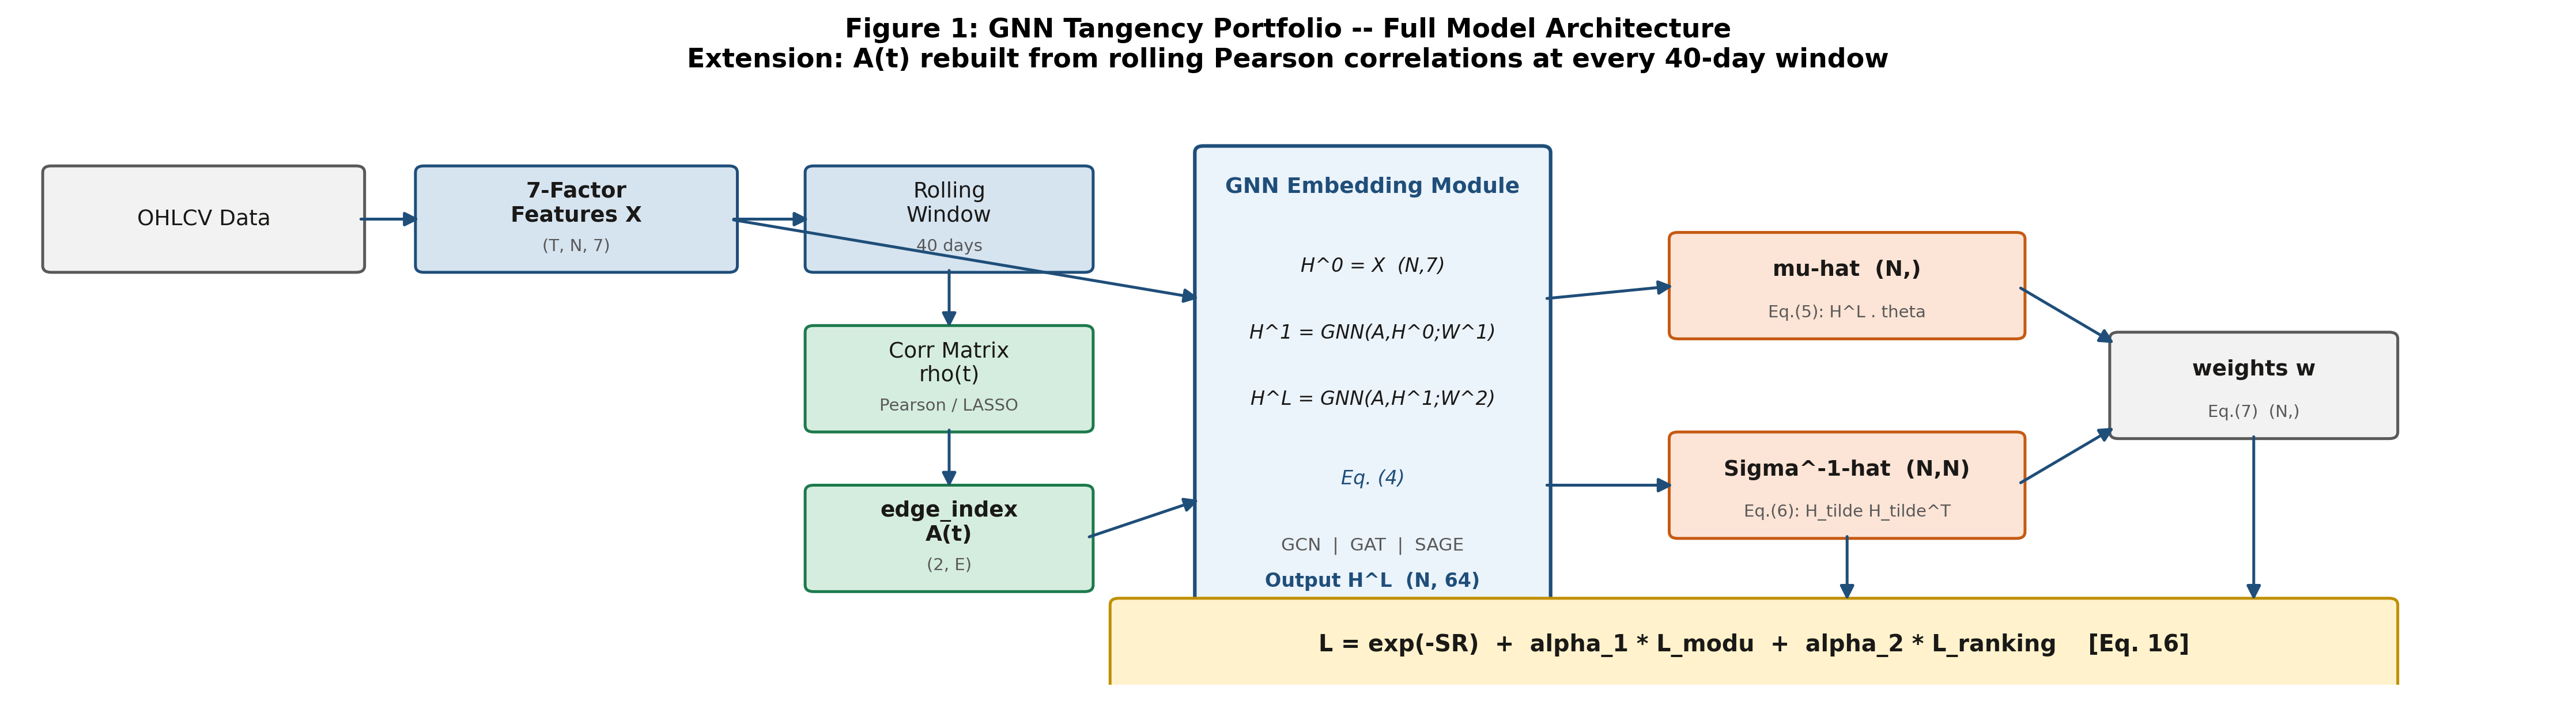

Saved: diagram2_rolling_window.png

  Figure 2: Rolling Window + Correlation + Graph


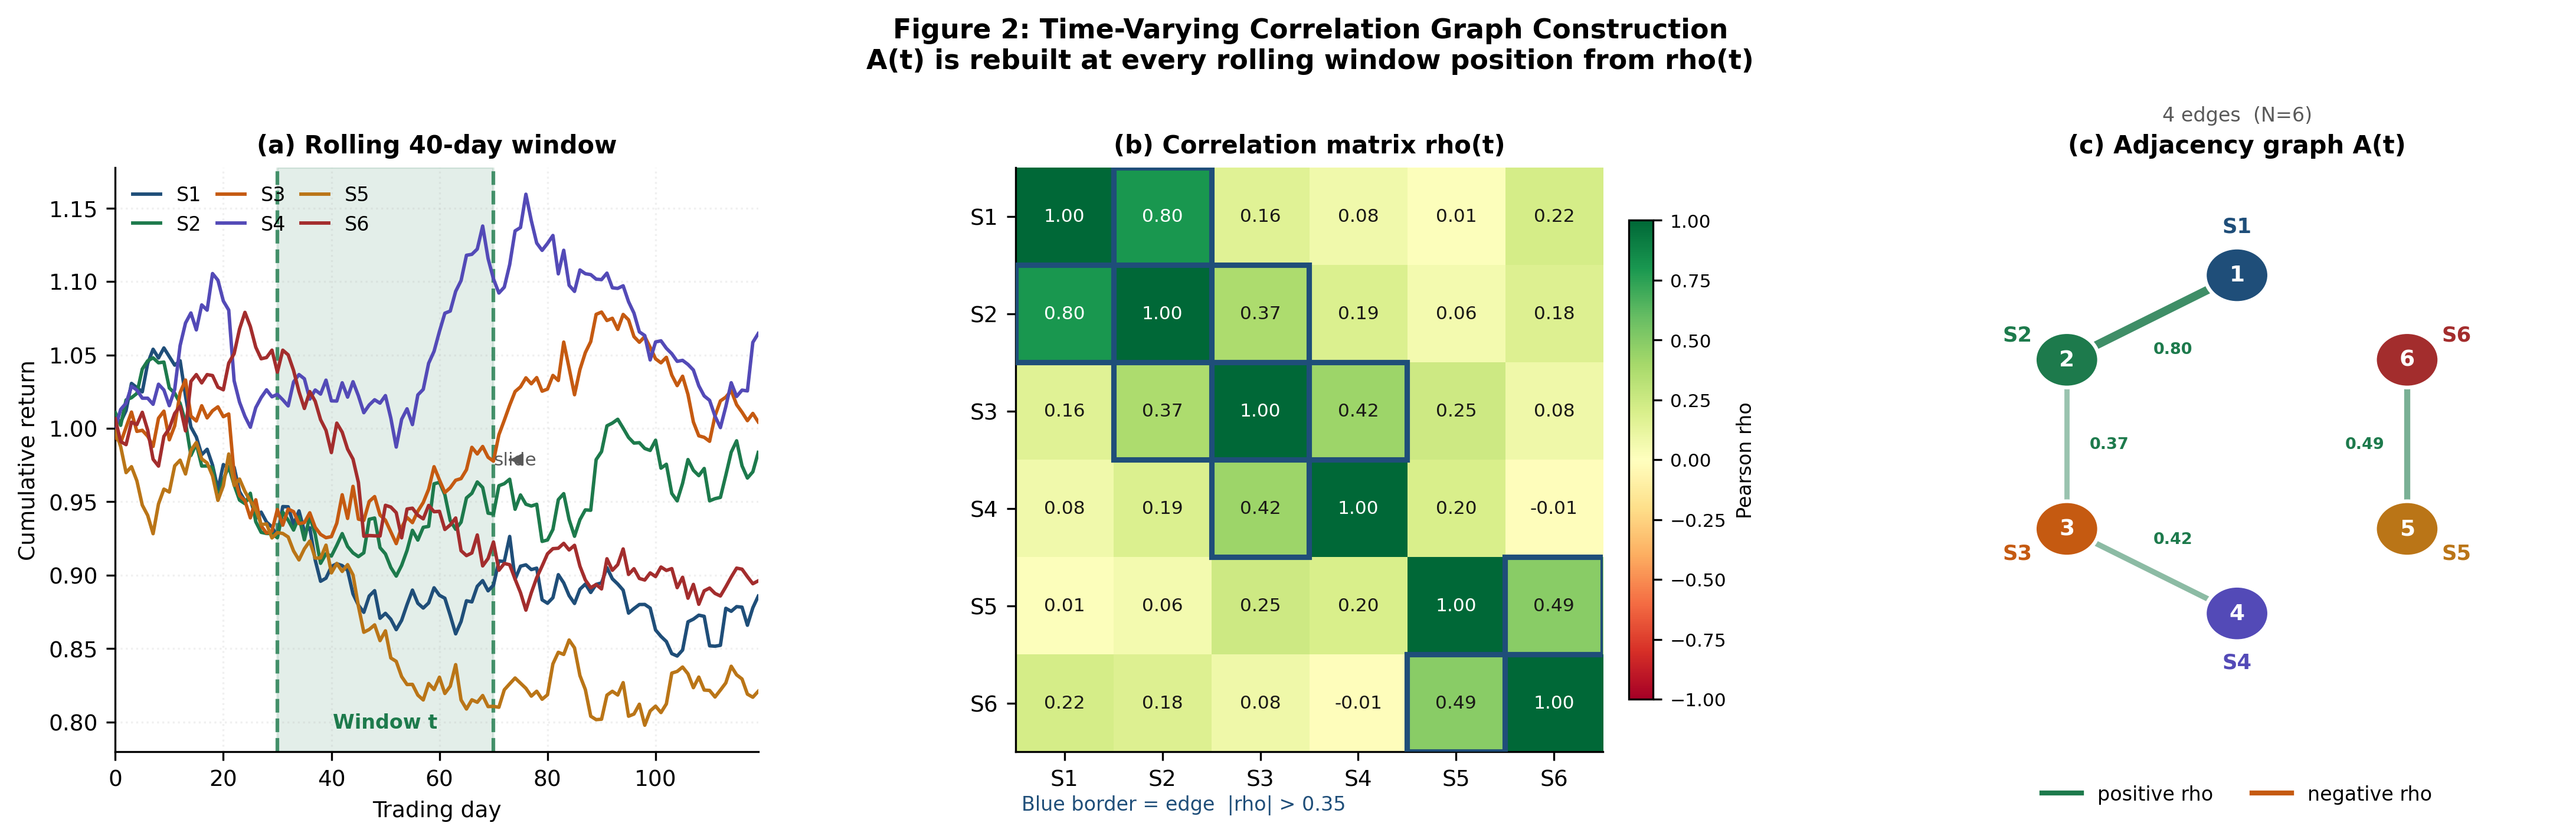

Saved: diagram3_gnn_architectures.png

  Figure 3: GCN vs GraphSAGE vs GAT


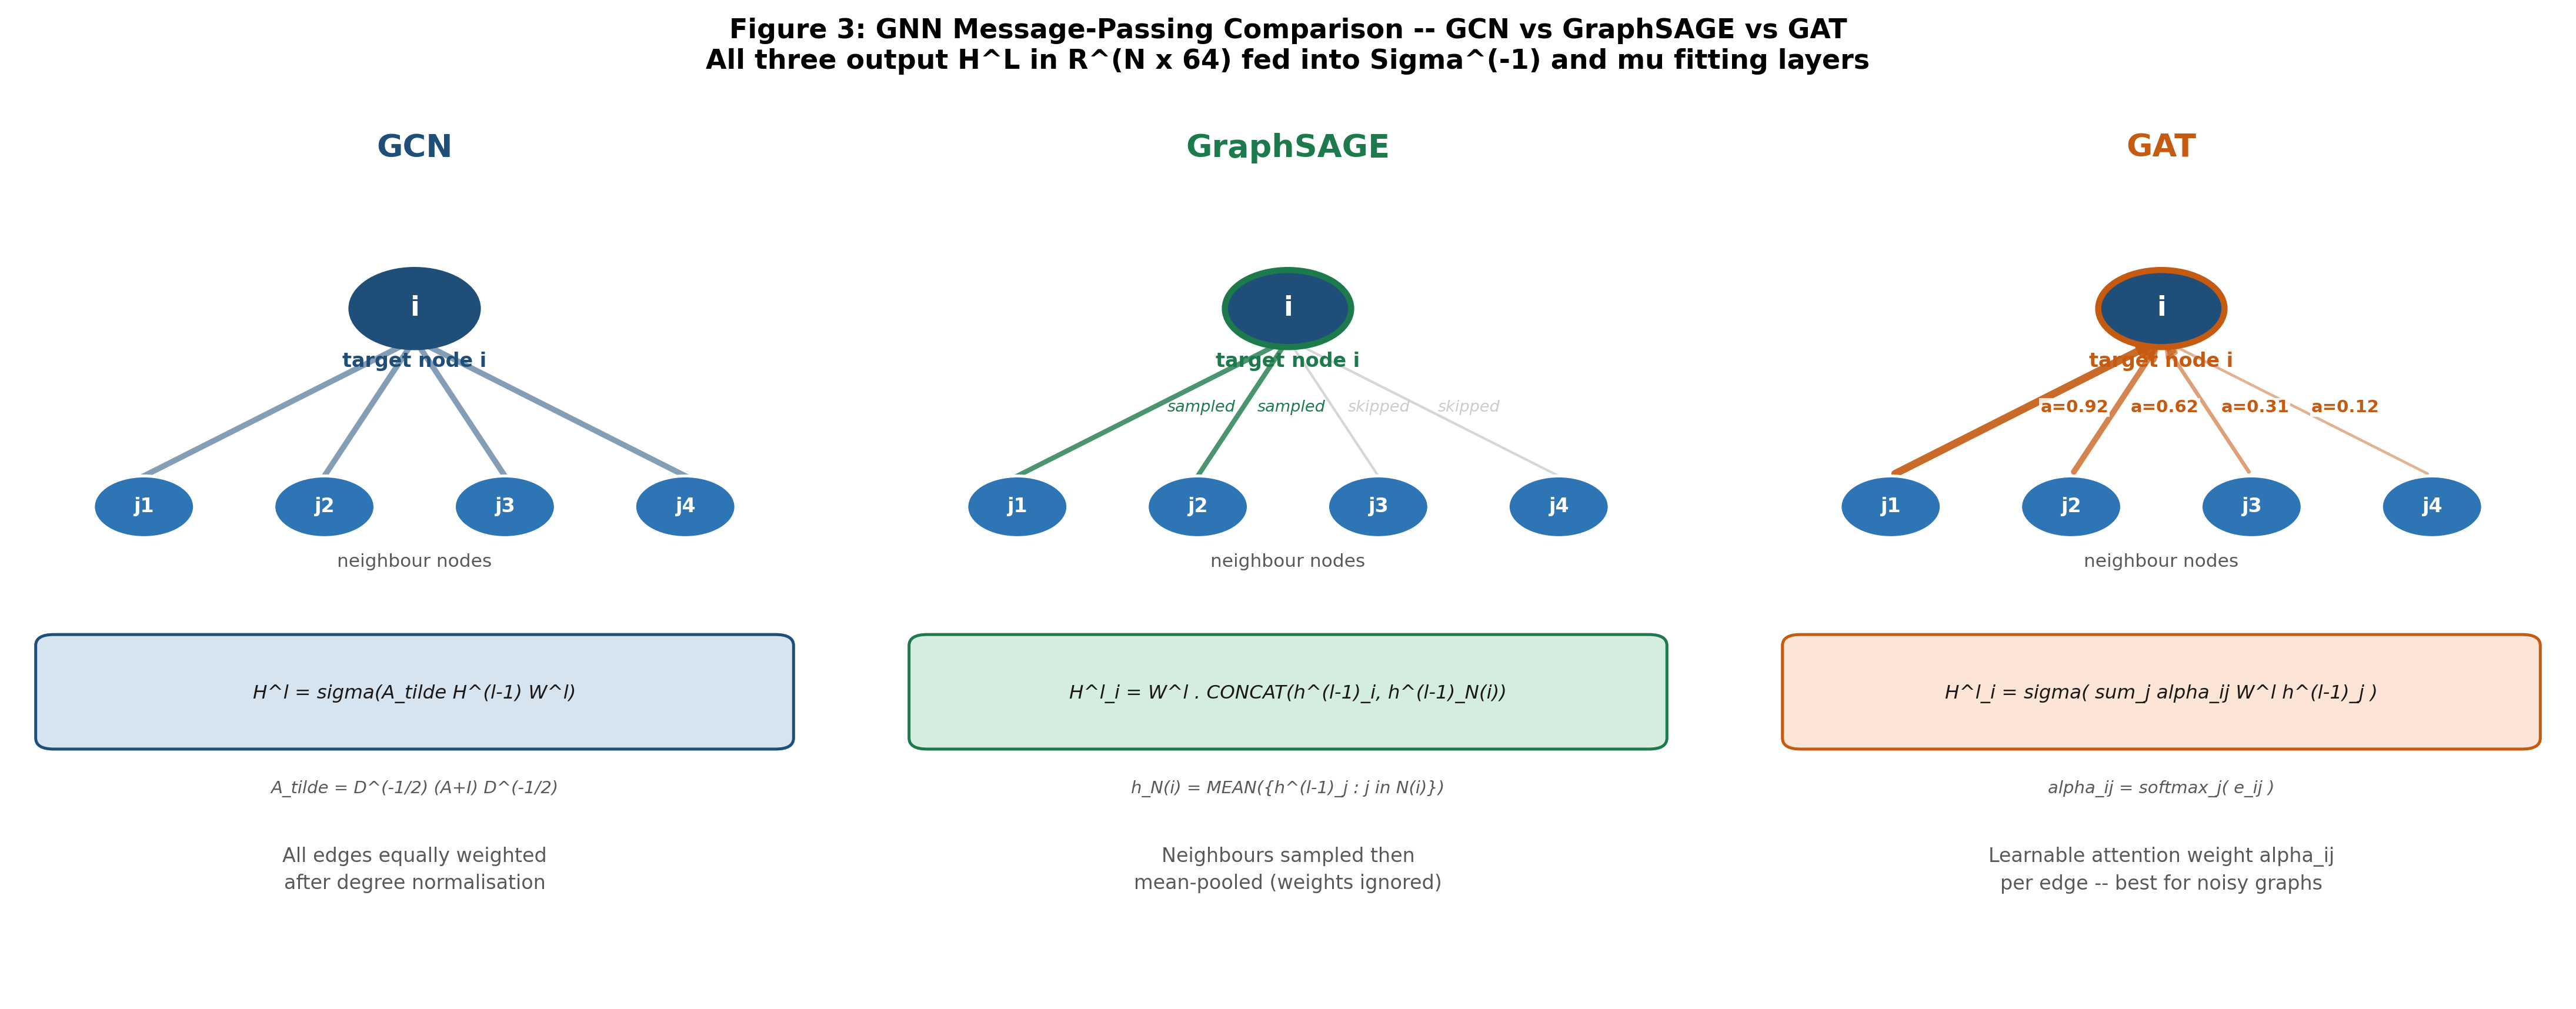

Saved: diagram4_loss_decomposition.png

  Figure 4: Loss Function Decomposition (Eq. 16)


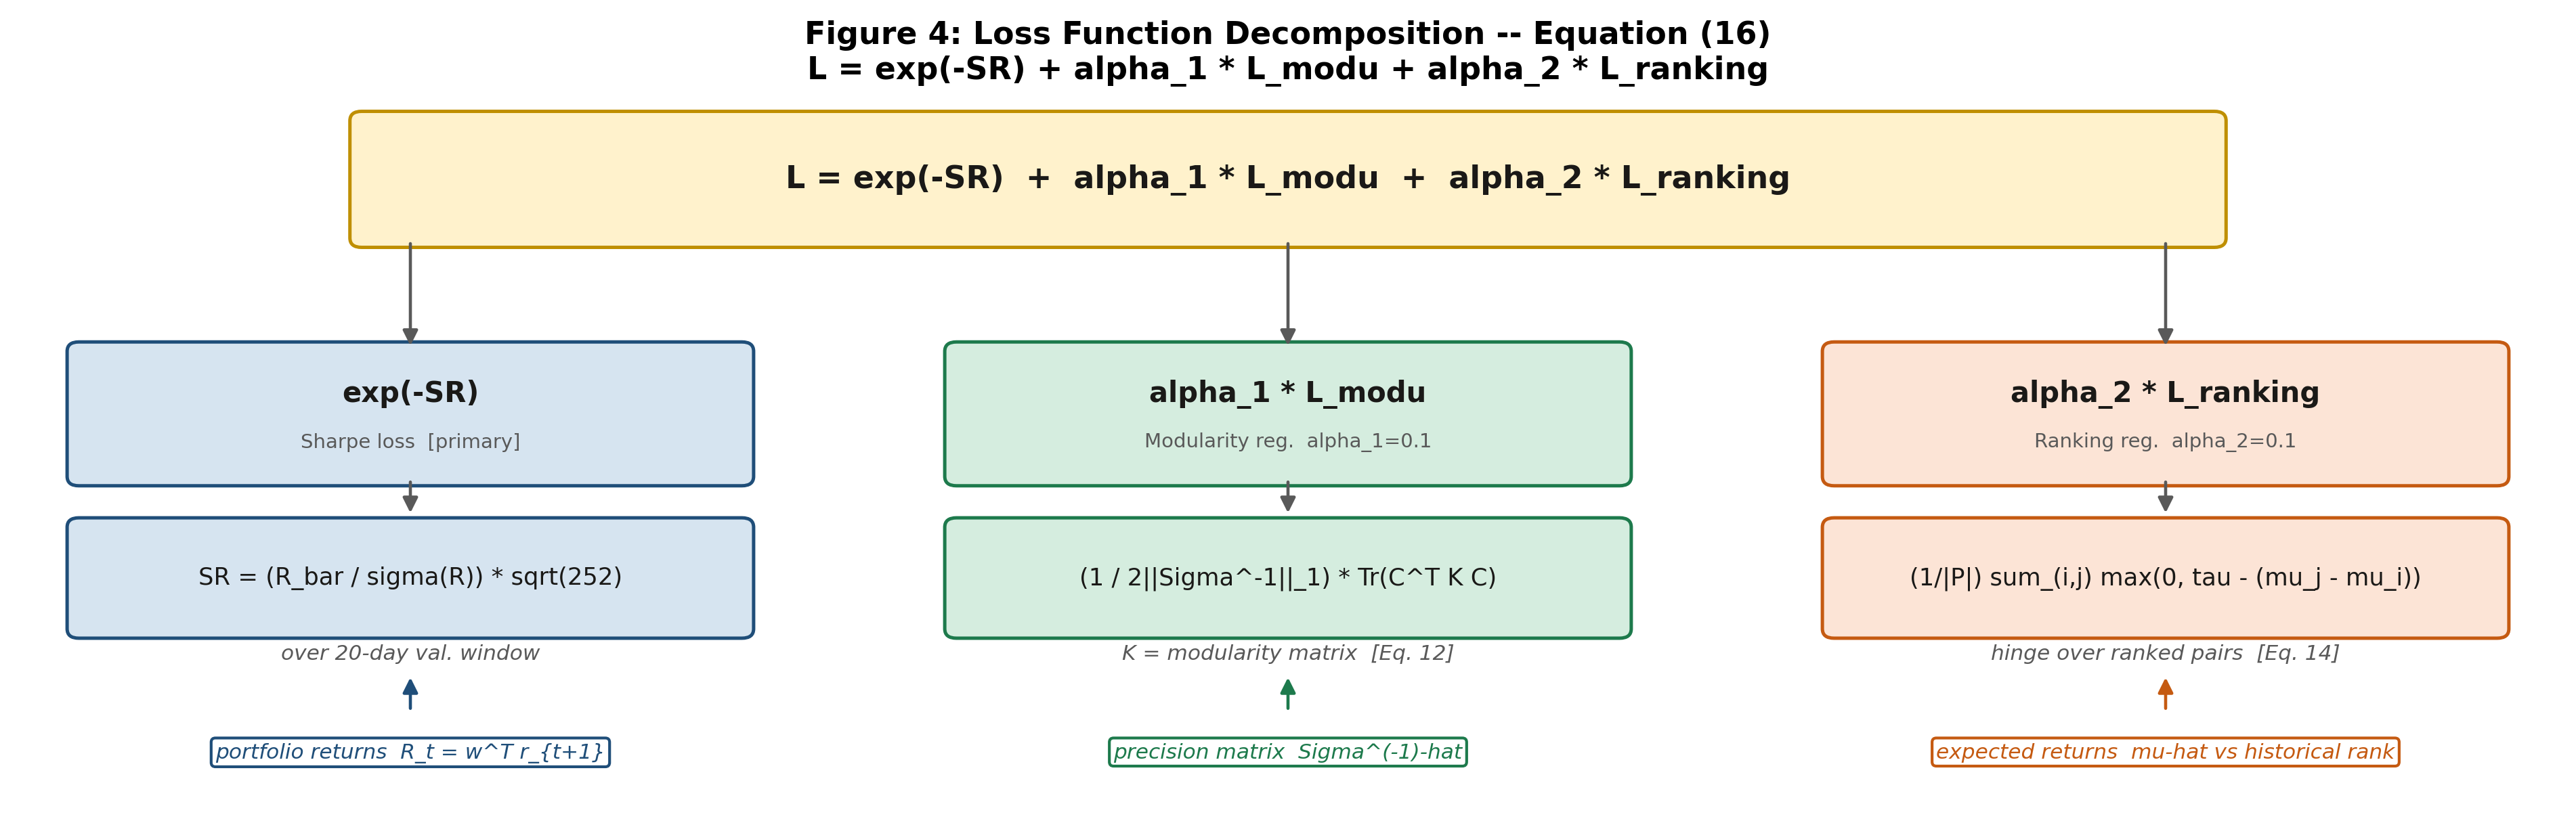

Saved: diagram5_adjacency_heatmaps.png

  Figure 5: Adjacency Matrix Comparison


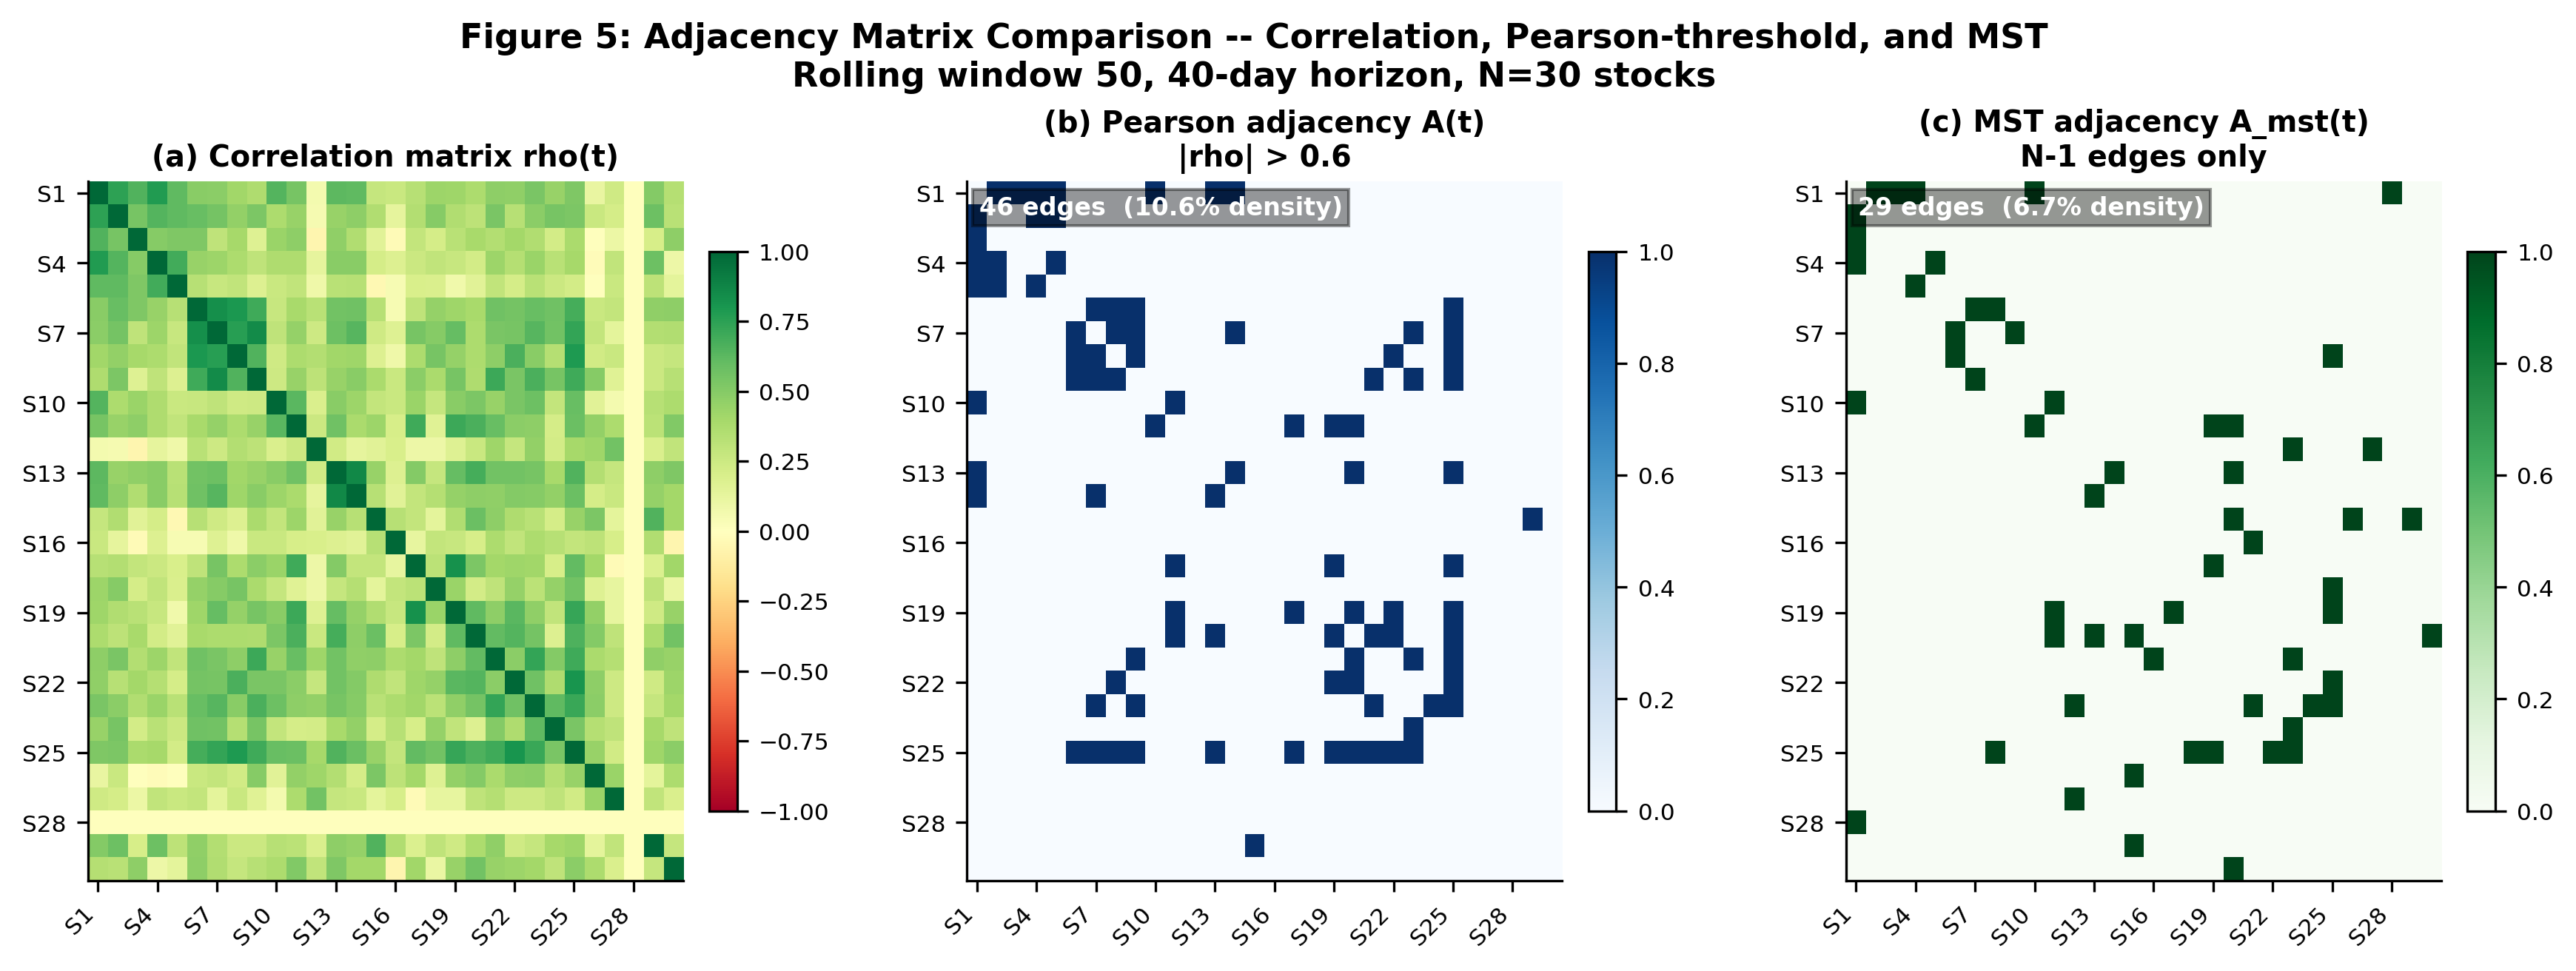

  all_metrics not found -- run Cell 21 first for diagram 6
  all_log_dfs not found -- run Cell 21 first for diagram 7
  all_metrics not found -- run Cell 21 first for diagram 8

  All diagrams complete. Saved to: /content/

Data requirements:
  1-5  run immediately (no pipeline output needed)
  6-8  need all_metrics / all_log_dfs from Cell 21


In [ ]:
"""
paper_diagrams.py  (v3 -- fixed rendering)
===========================================
Generates all publication figures matching Liu et al. (2026) style.

Fixes applied vs v2:
  - diagram2: black image fixed (Agg backend forced, cov matrix scaled correctly)
  - diagram3: node layout changed to tree/star so labels never overlap;
              each arch drawn in its own subplot (set_aspect dropped)
  - diagram6: cumulative return axis normalised to start at 1.0 not raw cumprod
  - diagram_table: NEW -- formatted results table figure from actual metrics
  - all figures: usetex=False (avoids LaTeX not installed errors in Colab)

Run AFTER Cell 21 (pipeline) to get diagrams 5,6,7,8 and the table.
Diagrams 1-4 and the table run immediately with no pipeline output needed
(table uses the all_metrics dict if present, or the hardcoded values below).
"""

import numpy as np
import matplotlib
matplotlib.use("Agg")            # force non-interactive backend -- fixes black image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Style: match paper aesthetic
# ---------------------------------------------------------------------------
matplotlib.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.size":          10,
    "axes.titlesize":     11,
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.10,
    "text.usetex":        False,   # no LaTeX installation needed
})

# Colour palette
CB   = "#1F4E79"   # dark blue
CM   = "#2E75B6"   # mid blue
CL   = "#D6E4F0"   # light blue
CG   = "#1D7A4C"   # green
CLG  = "#D5EDDF"   # light green
CO   = "#C55A11"   # orange
CLO  = "#FCE4D6"   # light orange
CGY  = "#595959"   # dark grey
CLGY = "#F2F2F2"   # light grey
CRED = "#A32D2D"   # red
BLACK= "#1A1917"

SAVE = "/content/"   # change to "./" if running locally

# ===========================================================================
# Diagram 1 -- Full model architecture pipeline
# ===========================================================================
def diagram1_model_architecture():
    fig, ax = plt.subplots(figsize=(15, 4.5))
    fig.patch.set_facecolor("white")
    ax.set_xlim(0, 15); ax.set_ylim(0, 4.5)
    ax.axis("off")

    def box(cx, cy, w, h, text, sub="", fc=CL, ec=CB, bold=False, tc=BLACK, fs=9):
        r = FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                           boxstyle="round,pad=0.05",
                           facecolor=fc, edgecolor=ec, linewidth=1.2, zorder=3)
        ax.add_patch(r)
        oy = 0.12 if sub else 0
        ax.text(cx, cy + oy, text, ha="center", va="center",
                fontsize=fs, fontweight="bold" if bold else "normal",
                color=tc, zorder=4)
        if sub:
            ax.text(cx, cy - 0.20, sub, ha="center", va="center",
                    fontsize=7, color=CGY, zorder=4)

    def arr(x1, y1, x2, y2, col=CB):
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="-|>", color=col,
                                    lw=1.2, mutation_scale=12), zorder=5)

    # Input
    box(1.1, 3.5, 1.8, 0.70, "OHLCV Data", fc=CLGY, ec=CGY)
    box(3.3, 3.5, 1.8, 0.70, "7-Factor\nFeatures X", sub="(T, N, 7)",
        fc=CL, ec=CB, bold=True)

    # Rolling window + graph branch
    box(5.5, 3.5, 1.6, 0.70, "Rolling\nWindow", sub="40 days", fc=CL, ec=CB)
    box(5.5, 2.3, 1.6, 0.70, "Corr Matrix\nrho(t)", sub="Pearson / LASSO",
        fc=CLG, ec=CG)
    box(5.5, 1.1, 1.6, 0.70, "edge_index\nA(t)", sub="(2, E)", fc=CLG, ec=CG, bold=True)

    # GNN block
    gnn_rect = FancyBboxPatch((7.0, 0.60), 2.0, 3.40,
                               boxstyle="round,pad=0.05",
                               facecolor="#EBF3FB", edgecolor=CB,
                               linewidth=1.5, zorder=3)
    ax.add_patch(gnn_rect)
    ax.text(8.0, 3.70, "GNN Embedding Module", ha="center",
            fontsize=9, fontweight="bold", color=CB, zorder=4)
    for y_t, txt in [(3.15, "H^0 = X  (N,7)"),
                      (2.65, "H^1 = GNN(A,H^0;W^1)"),
                      (2.15, "H^L = GNN(A,H^1;W^2)"),
                      (1.55, "Eq. (4)"),
                      (1.05, "GCN  |  GAT  |  SAGE")]:
        fs_t = 8 if y_t > 1.2 else 7.5
        col_t = CB if y_t == 1.55 else (CGY if y_t == 1.05 else BLACK)
        ax.text(8.0, y_t, txt, ha="center", va="center",
                fontsize=fs_t, color=col_t, zorder=4,
                style="italic" if y_t > 1.2 else "normal")
    ax.text(8.0, 0.78, "Output H^L  (N, 64)", ha="center", va="center",
            fontsize=8, color=CB, fontweight="bold", zorder=4)

    # Fitter outputs
    box(10.8, 3.0, 2.0, 0.70, "mu-hat  (N,)", sub="Eq.(5): H^L . theta",
        fc=CLO, ec=CO, bold=True)
    box(10.8, 1.5, 2.0, 0.70, "Sigma^-1-hat  (N,N)", sub="Eq.(6): H_tilde H_tilde^T",
        fc=CLO, ec=CO, bold=True)

    # Weights
    box(13.2, 2.25, 1.6, 0.70, "weights w", sub="Eq.(7)  (N,)",
        fc=CLGY, ec=CGY, bold=True)

    # Loss bar
    loss_rect = FancyBboxPatch((6.5, 0.0), 7.5, 0.60,
                                boxstyle="round,pad=0.05",
                                facecolor="#FFF2CC", edgecolor="#BF8F00",
                                linewidth=1.2, zorder=3)
    ax.add_patch(loss_rect)
    ax.text(10.25, 0.30,
            "L = exp(-SR)  +  alpha_1 * L_modu  +  alpha_2 * L_ranking    [Eq. 16]",
            ha="center", va="center", fontsize=9.5,
            fontweight="bold", color=BLACK, zorder=4)

    # Arrows
    arr(2.0, 3.5, 2.4, 3.5)
    arr(4.2, 3.5, 4.7, 3.5)
    arr(5.5, 3.15, 5.5, 2.65)
    arr(5.5, 1.95, 5.5, 1.45)
    arr(4.2, 3.5, 7.0, 2.90)
    arr(6.3, 1.1, 7.0, 1.40)
    arr(9.0, 2.90, 9.8, 3.00)
    arr(9.0, 1.50, 9.8, 1.50)
    arr(11.8, 3.0, 12.4, 2.55)
    arr(11.8, 1.5, 12.4, 1.95)
    arr(13.2, 1.90, 13.2, 0.60)
    arr(10.8, 1.15, 10.8, 0.60)

    ax.set_title(
        "Figure 1: GNN Tangency Portfolio -- Full Model Architecture\n"
        "Extension: A(t) rebuilt from rolling Pearson correlations at every 40-day window",
        fontsize=11, fontweight="bold", pad=8)

    fig.subplots_adjust(left=0.01, right=0.99, top=0.82, bottom=0.05)
    plt.savefig(SAVE + "diagram1_model_architecture.png")
    plt.close()
    print("Saved: diagram1_model_architecture.png")


# ===========================================================================
# Diagram 2 -- Rolling window construction
# ===========================================================================
def diagram2_rolling_window(R_sample=None, N_show=6):
    """
    Fixed v3:
      - matplotlib.use("Agg") called at module level prevents black image
      - cov matrix scaled to realistic daily return variance (~0.01^2)
      - labels positioned outside the node circles to avoid overlap
      - fig.savefig then plt.close() -- never plt.show() in Agg mode
    """
    np.random.seed(42)
    T_full = 120

    if R_sample is not None:
        N_show = min(N_show, R_sample.shape[1])
        rets   = R_sample[:T_full, :N_show].astype(float)
    else:
        # Realistic daily return covariance (~1% daily vol)
        base = np.array([
            [1.00, 0.72, 0.20, 0.10, 0.05, 0.02],
            [0.72, 1.00, 0.28, 0.10, 0.05, 0.02],
            [0.20, 0.28, 1.00, 0.62, 0.10, 0.05],
            [0.10, 0.10, 0.62, 1.00, 0.10, 0.05],
            [0.05, 0.05, 0.10, 0.10, 1.00, 0.58],
            [0.02, 0.02, 0.05, 0.05, 0.58, 1.00],
        ])
        # Scale to daily variance ~0.01^2
        std_daily = 0.012
        cov = base * (std_daily ** 2)
        L   = np.linalg.cholesky(cov + np.eye(N_show) * 1e-10)
        rets = (L @ np.random.randn(N_show, T_full)).T   # (T_full, N_show)

    cum   = np.cumprod(1 + rets, axis=0)
    WIN   = 40
    WIN_S = 30
    WIN_E = WIN_S + WIN

    window = rets[WIN_S:WIN_E]
    corr   = np.corrcoef(window.T)
    corr   = np.nan_to_num(corr, nan=0.0)

    THRESH = 0.35
    adj    = (np.abs(corr) > THRESH).astype(float)
    np.fill_diagonal(adj, 0)

    COLORS = [CB, CG, CO, "#534AB7", "#BA7517", CRED]
    LABELS = ["S1", "S2", "S3", "S4", "S5", "S6"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5.0))
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(wspace=0.40, top=0.80, bottom=0.14, left=0.05, right=0.97)

    # ---- Panel (a): cumulative returns with sliding window ----
    ax = axes[0]
    ax.set_facecolor("white")
    ax.axvspan(WIN_S, WIN_E, alpha=0.12, color=CG, zorder=1)
    ax.axvline(WIN_S, color=CG, lw=1.5, ls="--", zorder=2, alpha=0.8)
    ax.axvline(WIN_E, color=CG, lw=1.5, ls="--", zorder=2, alpha=0.8)

    for i in range(N_show):
        ax.plot(range(T_full), cum[:, i], color=COLORS[i],
                lw=1.4, label=LABELS[i], zorder=3)

    ax.set_xlim(0, T_full - 1)
    ax.set_xlabel("Trading day", fontsize=9)
    ax.set_ylabel("Cumulative return", fontsize=9)
    ax.set_title("(a) Rolling 40-day window", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, frameon=False, ncol=3, loc="upper left",
              handlelength=1.4, columnspacing=0.8)

    ylo, yhi = ax.get_ylim()
    ax.text((WIN_S + WIN_E) / 2, ylo + (yhi - ylo) * 0.04,
            "Window t", ha="center", fontsize=8,
            color=CG, fontweight="bold")
    ax.annotate("slide", xy=(WIN_E + 3, (ylo + yhi) / 2),
                xytext=(WIN_E, (ylo + yhi) / 2),
                arrowprops=dict(arrowstyle="-|>", color=CGY, lw=1.0,
                                mutation_scale=10),
                fontsize=7.5, color=CGY, ha="left", va="center")
    ax.grid(True, alpha=0.18, linestyle=":")

    # ---- Panel (b): correlation heatmap ----
    ax2 = axes[1]
    ax2.set_facecolor("white")
    im  = ax2.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1,
                     aspect="auto", interpolation="nearest")
    cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, shrink=0.82)
    cbar.set_label("Pearson rho", fontsize=8)
    cbar.ax.tick_params(labelsize=7.5)

    ax2.set_xticks(range(N_show))
    ax2.set_xticklabels(LABELS, fontsize=9)
    ax2.set_yticks(range(N_show))
    ax2.set_yticklabels(LABELS, fontsize=9)
    ax2.set_title("(b) Correlation matrix rho(t)", fontsize=10, fontweight="bold")

    for i in range(N_show):
        for j in range(N_show):
            val  = corr[i, j]
            edge = (i != j) and (abs(val) > THRESH)
            if edge:
                rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                     fill=False, edgecolor=CB,
                                     lw=2.2, zorder=4)
                ax2.add_patch(rect)
            tc = "white" if abs(val) > 0.65 else BLACK
            ax2.text(j, i, "{:.2f}".format(val), ha="center", va="center",
                     fontsize=7.5, color=tc, zorder=5)

    ax2.text(0.01, -0.10, "Blue border = edge  |rho| > {}".format(THRESH),
             transform=ax2.transAxes, fontsize=8, color=CB)

    # ---- Panel (c): resulting graph -- FIXED label placement ----
    ax3 = axes[2]
    ax3.set_facecolor("white")
    ax3.set_xlim(-1.8, 1.8)
    ax3.set_ylim(-2.0, 1.8)
    ax3.axis("off")
    ax3.set_title("(c) Adjacency graph A(t)", fontsize=10, fontweight="bold")

    # Node positions on a hexagon
    angs = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, N_show, endpoint=False)
    pos  = {i: (np.cos(a) * 1.1, np.sin(a) * 1.1) for i, a in enumerate(angs)}
    # Label offsets -- push labels further out from node centre
    lbl_pos = {i: (np.cos(a) * 1.42, np.sin(a) * 1.42) for i, a in enumerate(angs)}

    # Draw edges
    for i in range(N_show):
        for j in range(i + 1, N_show):
            if adj[i, j] > 0:
                xi, yi = pos[i]; xj, yj = pos[j]
                rho    = corr[i, j]
                lw_e   = 1.0 + abs(rho) * 3.0
                col_e  = CG if rho > 0 else CO
                ax3.plot([xi, xj], [yi, yj], color=col_e,
                         lw=lw_e, alpha=min(abs(rho) * 1.2, 0.85), zorder=1)
                # Edge weight label at midpoint -- offset slightly to avoid node overlap
                mx = (xi + xj) / 2 * 0.75
                my = (yi + yj) / 2 * 0.75
                ax3.text(mx, my, "{:.2f}".format(rho), ha="center", va="center",
                         fontsize=6.5, color=col_e, fontweight="bold",
                         bbox=dict(fc="white", ec="none", pad=0.4, alpha=0.85),
                         zorder=3)

    # Draw nodes (smaller radius so labels outside do not overlap)
    R_node = 0.18
    for i in range(N_show):
        xi, yi = pos[i]
        circ = plt.Circle((xi, yi), R_node, color=COLORS[i],
                          zorder=4, ec="white", lw=1.5)
        ax3.add_patch(circ)
        ax3.text(xi, yi, str(i + 1), ha="center", va="center",
                 fontsize=9, fontweight="bold", color="white", zorder=5)
        # Stock label outside the node
        lx, ly = lbl_pos[i]
        ax3.text(lx, ly, LABELS[i], ha="center", va="center",
                 fontsize=8.5, color=COLORS[i], fontweight="bold", zorder=5)

    # Legend
    ax3.plot([], [], color=CG,  lw=2, label="positive rho")
    ax3.plot([], [], color=CO,  lw=2, label="negative rho")
    ax3.legend(fontsize=8, frameon=False, loc="lower center",
               bbox_to_anchor=(0.5, -0.12), ncol=2)
    n_edges = int(adj.sum() // 2)
    ax3.text(0.5, 1.08, "{} edges  (N={})".format(n_edges, N_show),
             transform=ax3.transAxes, ha="center", fontsize=8, color=CGY)

    fig.suptitle(
        "Figure 2: Time-Varying Correlation Graph Construction\n"
        "A(t) is rebuilt at every rolling window position from rho(t)",
        fontsize=11, fontweight="bold", y=0.97)

    plt.savefig(SAVE + "diagram2_rolling_window.png")
    plt.close()
    print("Saved: diagram2_rolling_window.png")


# ===========================================================================
# Diagram 3 -- GCN vs SAGE vs GAT (FIXED: layout so text never overlaps)
# Key fix: use a TREE layout (root=i at top, neighbours below in a row)
# so the "target node i" label, equation boxes, and descriptions are all
# in separate vertical zones with guaranteed non-overlapping space.
# ===========================================================================
def diagram3_gnn_architectures():
    """
    Fixed v3:
      - Tree layout: central node i at top, neighbour nodes in a row below
      - Each architecture in its own subplot with axis("off") and generous margins
      - Equation and description placed in a fixed lower zone per subplot
      - No set_aspect("equal") -- this was cutting off text in the original
    """
    archs = [
        {
            "name": "GCN",
            "color": CB, "fill": CL,
            "eq":  "H^l = sigma(A_tilde H^(l-1) W^l)",
            "eq2": "A_tilde = D^(-1/2) (A+I) D^(-1/2)",
            "desc": "All edges equally weighted\nafter degree normalisation",
            "weights": [1.0, 1.0, 1.0, 1.0],
            "sampled": None,
        },
        {
            "name": "GraphSAGE",
            "color": CG, "fill": CLG,
            "eq":  "H^l_i = W^l . CONCAT(h^(l-1)_i, h^(l-1)_N(i))",
            "eq2": "h_N(i) = MEAN({h^(l-1)_j : j in N(i)})",
            "desc": "Neighbours sampled then\nmean-pooled (weights ignored)",
            "weights": [1.0, 1.0, 1.0, 1.0],
            "sampled": [True, True, False, False],
        },
        {
            "name": "GAT",
            "color": CO, "fill": CLO,
            "eq":  "H^l_i = sigma( sum_j alpha_ij W^l h^(l-1)_j )",
            "eq2": "alpha_ij = softmax_j( e_ij )",
            "desc": "Learnable attention weight alpha_ij\nper edge -- best for noisy graphs",
            "weights": [0.92, 0.62, 0.31, 0.12],
            "sampled": None,
        },
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 6.0))
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(wspace=0.10, top=0.82, bottom=0.05,
                        left=0.02, right=0.98)

    # Node positions: tree layout
    # Central node i at (0, 0.6); neighbours j1..j4 in a row at y=-0.3
    ROOT   = (0.0, 0.6)
    NB_XS  = [-0.75, -0.25, 0.25, 0.75]
    NB_Y   = -0.30
    NB_POS = [(x, NB_Y) for x in NB_XS]
    NB_LBL = ["j1", "j2", "j3", "j4"]
    R_NODE = 0.14    # node radius

    for ax, arch in zip(axes, archs):
        ax.set_facecolor("white")
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-2.5, 1.2)
        ax.axis("off")
        color = arch["color"]
        fill  = arch["fill"]

        # Draw edges from each neighbour to root
        for k, (nx, ny) in enumerate(NB_POS):
            rx, ry = ROOT
            w = arch["weights"][k]
            lw_e = 0.8 + w * 2.5

            if arch["sampled"] is not None:
                # SAGE: colour by sampled/skipped
                sampled = arch["sampled"][k]
                col_e   = CG if sampled else "#CCCCCC"
                lw_e    = 2.0 if sampled else 1.0
                ax.plot([nx, rx], [ny + R_NODE, ry - R_NODE],
                        color=col_e, lw=lw_e, alpha=0.8, zorder=1)
                # Label: "sampled" or "skipped" on the edge
                mx = (nx + rx) / 2
                my = (ny + R_NODE + ry - R_NODE) / 2
                lbl = "sampled" if sampled else "skipped"
                ax.text(mx + 0.04, my, lbl, ha="left", va="center",
                        fontsize=6.5, color=col_e, style="italic")

            elif arch["name"] == "GAT":
                # GAT: arrow with attention weight label
                ax.annotate("",
                    xy=(rx, ry - R_NODE),
                    xytext=(nx, ny + R_NODE),
                    arrowprops=dict(arrowstyle="-|>", color=color,
                                    lw=lw_e, alpha=0.4 + w * 0.55,
                                    mutation_scale=10),
                    zorder=1)
                mx = (nx + rx) / 2
                my = (ny + R_NODE + ry - R_NODE) / 2
                ax.text(mx + 0.04, my, "a={:.2f}".format(w),
                        ha="left", va="center", fontsize=7,
                        color=color, fontweight="bold",
                        bbox=dict(fc="white", ec="none", pad=0.5,
                                  alpha=0.85))
            else:
                # GCN: plain equal-weight edges
                ax.plot([nx, rx], [ny + R_NODE, ry - R_NODE],
                        color=color, lw=lw_e * 0.7, alpha=0.55, zorder=1)

        # Draw neighbour nodes
        for k, (nx, ny) in enumerate(NB_POS):
            circ = plt.Circle((nx, ny), R_NODE, color=CM,
                              zorder=4, ec="white", lw=1.2)
            ax.add_patch(circ)
            ax.text(nx, ny, NB_LBL[k], ha="center", va="center",
                    fontsize=8, fontweight="bold", color="white", zorder=5)

        # Draw root node (larger, accented border)
        rx, ry = ROOT
        circ_root = plt.Circle((rx, ry), R_NODE * 1.25, color=CB,
                                zorder=4, ec=color, lw=2.5)
        ax.add_patch(circ_root)
        ax.text(rx, ry, "i", ha="center", va="center",
                fontsize=11, fontweight="bold", color="white", zorder=5)

        # Labels below root and above neighbour row
        ax.text(rx, ry - R_NODE * 1.4, "target node i",
                ha="center", va="top", fontsize=8, color=color,
                fontweight="bold")
        ax.text(0.0, NB_Y - R_NODE * 1.5, "neighbour nodes",
                ha="center", va="top", fontsize=7.5, color=CGY)

        # Equation box (fixed zone: y = -1.15)
        eq_y = -1.15
        eq_box = FancyBboxPatch((-1.0, eq_y - 0.20), 2.0, 0.42,
                                 boxstyle="round,pad=0.05",
                                 facecolor=fill, edgecolor=color,
                                 linewidth=1.2, zorder=3)
        ax.add_patch(eq_box)
        ax.text(0.0, eq_y, arch["eq"], ha="center", va="center",
                fontsize=7.8, color=BLACK, style="italic", zorder=4)

        # Sub-equation (fixed zone: y = -1.55)
        ax.text(0.0, -1.58, arch["eq2"], ha="center", va="center",
                fontsize=7.0, color=CGY, style="italic")

        # Description text (fixed zone: y = -1.95)
        ax.text(0.0, -1.95, arch["desc"], ha="center", va="center",
                fontsize=8, color=CGY, linespacing=1.5)

        ax.set_title(arch["name"], fontsize=13, fontweight="bold",
                     color=color, pad=8)

    fig.suptitle(
        "Figure 3: GNN Message-Passing Comparison -- GCN vs GraphSAGE vs GAT\n"
        "All three output H^L in R^(N x 64) fed into Sigma^(-1) and mu fitting layers",
        fontsize=11, fontweight="bold", y=0.97)

    plt.savefig(SAVE + "diagram3_gnn_architectures.png")
    plt.close()
    print("Saved: diagram3_gnn_architectures.png")


# ===========================================================================
# Diagram 4 -- Loss decomposition
# ===========================================================================
def diagram4_loss_decomposition():
    fig, ax = plt.subplots(figsize=(13, 4.5))
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(left=0.02, right=0.98, top=0.82, bottom=0.05)
    ax.set_xlim(0, 13); ax.set_ylim(0, 4.5)
    ax.axis("off")

    def rbox(cx, cy, w, h, txt, fc, ec, fs=9, bold=False, sub=None):
        r = FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                           boxstyle="round,pad=0.06",
                           facecolor=fc, edgecolor=ec, linewidth=1.2, zorder=3)
        ax.add_patch(r)
        oy = 0.13 if sub else 0
        ax.text(cx, cy + oy, txt, ha="center", va="center",
                fontsize=fs, color=BLACK, fontweight="bold" if bold else "normal",
                zorder=4)
        if sub:
            ax.text(cx, cy - 0.18, sub, ha="center", va="center",
                    fontsize=7, color=CGY, zorder=4)

    def arr(x1, y1, x2, y2, col=CGY):
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="-|>", color=col,
                                    lw=1.1, mutation_scale=11), zorder=5)

    # Total loss
    rbox(6.5, 4.0, 9.5, 0.75,
         "L = exp(-SR)  +  alpha_1 * L_modu  +  alpha_2 * L_ranking",
         fc="#FFF2CC", ec="#BF8F00", fs=11, bold=True)

    # Three terms
    rbox(2.0,  2.5, 3.4, 0.8, "exp(-SR)",
         fc=CL,  ec=CB, fs=10, bold=True, sub="Sharpe loss  [primary]")
    rbox(6.5,  2.5, 3.4, 0.8, "alpha_1 * L_modu",
         fc=CLG, ec=CG, fs=10, bold=True, sub="Modularity reg.  alpha_1=0.1")
    rbox(11.0, 2.5, 3.4, 0.8, "alpha_2 * L_ranking",
         fc=CLO, ec=CO, fs=10, bold=True, sub="Ranking reg.  alpha_2=0.1")

    for bx in [2.0, 6.5, 11.0]:
        arr(bx, 3.625, bx, 2.90)

    # Sub-equations
    eqs = [
        (2.0,  1.45, CL,  CB,
         "SR = (R_bar / sigma(R)) * sqrt(252)",
         "over 20-day val. window"),
        (6.5,  1.45, CLG, CG,
         "(1 / 2||Sigma^-1||_1) * Tr(C^T K C)",
         "K = modularity matrix  [Eq. 12]"),
        (11.0, 1.45, CLO, CO,
         "(1/|P|) sum_(i,j) max(0, tau - (mu_j - mu_i))",
         "hinge over ranked pairs  [Eq. 14]"),
    ]
    for bx, by, fc_, ec_, eq_, lbl_ in eqs:
        arr(bx, 2.10, bx, by + 0.38)
        rbox(bx, by, 3.4, 0.65, eq_, fc_, ec_, fs=8.5)
        ax.text(bx, by - 0.52, lbl_, ha="center", fontsize=7.5,
                color=CGY, style="italic")

    # Input sources
    sources = [
        (2.0,  "portfolio returns  R_t = w^T r_{t+1}", CB),
        (6.5,  "precision matrix  Sigma^(-1)-hat", CG),
        (11.0, "expected returns  mu-hat vs historical rank", CO),
    ]
    for bx, inp, col in sources:
        ax.text(bx, 0.30, inp, ha="center", fontsize=7.5,
                color=col, style="italic",
                bbox=dict(fc="white", ec=col, pad=3,
                          boxstyle="round,pad=0.2"))
        arr(bx, 0.58, bx, 0.85, col=col)

    ax.set_title(
        "Figure 4: Loss Function Decomposition -- Equation (16)\n"
        "L = exp(-SR) + alpha_1 * L_modu + alpha_2 * L_ranking",
        fontsize=11, fontweight="bold", pad=8)

    plt.savefig(SAVE + "diagram4_loss_decomposition.png")
    plt.close()
    print("Saved: diagram4_loss_decomposition.png")


# ===========================================================================
# Diagram 5 -- Adjacency heatmaps
# ===========================================================================
def diagram5_adjacency_heatmaps(R_test=None, window_idx=50):
    np.random.seed(7)

    if R_test is not None:
        # Use actual test-period returns from the pipeline
        N  = min(R_test.shape[1], 30) # cap at 30 stocks for readability
        tl = 40           # window length
        wi = min(window_idx, R_test.shape[0] - tl - 1) # guard against out-of-bounds
        window = R_test[wi : wi + tl, :N].astype(float)
    else:
        # Synthetic fallback with random correlation structure
        N = 12; tl = 40
        std = 0.012
        base = np.eye(N) + np.random.rand(N, N) * 0.4
        base = (base + base.T) / 2
        np.fill_diagonal(base, 1.0)
        L = np.linalg.cholesky(base * std**2 + np.eye(N) * 1e-8)
        window = (L @ np.random.randn(N, tl)).T
    # ── Compute correlation matrix ─────────────────────────────────────────
    corr = np.corrcoef(window.T)
    corr = np.nan_to_num(corr, nan=0.0)

    # ── Pearson threshold adjacency ────────────────────────────────────────
    # Use threshold from global config if available, else 0.60
    THRESH = CFG["threshold"] if "CFG" in dir() else 0.60
    adj_p  = (np.abs(corr) > THRESH).astype(float)
    np.fill_diagonal(adj_p, 0)

    from scipy.sparse.csgraph import minimum_spanning_tree
    from scipy.sparse import csr_matrix

    # Distance metric: d_ij in [0,2], smaller = more correlated
    dist    = np.sqrt(np.clip(2.0 * (1.0 - corr), 0.0, 4.0))
    np.fill_diagonal(dist, 0.0)
    # Kruskal's MST: keeps N-1 edges (maximally sparse connected graph)
    mst_out = minimum_spanning_tree(csr_matrix(dist)).toarray()
    # Convert directed MST output to symmetric undirected adjacency
    adj_mst = ((mst_out > 0) | (mst_out.T > 0)).astype(float)

    # Tick spacing — show every tick_s-th stock label on axes
    tick_s = max(1, N // 8)
    ticks  = list(range(0, N, tick_s))
    tlbls  = ["S{}".format(i + 1) for i in ticks]


    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(wspace=0.35, top=0.82, bottom=0.12)
    # Three panels share the same loop structure:
    # (data_matrix, colormap, vmin, vmax, title, adjacency_for_annotation)

    for ax, (data, cmap, vmin, vmax, title, adj_c) in zip(axes, [
        (corr,    "RdYlGn", -1, 1,
         "(a) Correlation matrix rho(t)", None),
        (adj_p,   "Blues",   0, 1,
         "(b) Pearson adjacency A(t)\n|rho| > {}".format(THRESH), adj_p),
        (adj_mst, "Greens",  0, 1,
         "(c) MST adjacency A_mst(t)\nN-1 edges only", adj_mst),
    ]):
        ax.set_facecolor("white")
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax,
                       aspect="auto", interpolation="nearest")
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.80)
        cbar.ax.tick_params(labelsize=7.5)
        ax.set_xticks(ticks); ax.set_xticklabels(tlbls, fontsize=7.5,
                                                   rotation=45, ha="right")
        ax.set_yticks(ticks); ax.set_yticklabels(tlbls, fontsize=7.5)
        ax.set_title(title, fontsize=9.5, fontweight="bold", pad=5)
        if adj_c is not None:
            n_e     = int(adj_c.sum() // 2)
            density = n_e / max(N * (N - 1) / 2, 1)
            ax.text(0.02, 0.98,
                    "{} edges  ({:.1%} density)".format(n_e, density),
                    transform=ax.transAxes, fontsize=8, color="white",
                    va="top", fontweight="bold",
                    bbox=dict(fc="black", alpha=0.40, pad=2))

    fig.suptitle(
        "Figure 5: Adjacency Matrix Comparison -- Correlation, "
        "Pearson-threshold, and MST\n"
        "Rolling window {}, {}-day horizon, N={} stocks".format(
            window_idx, tl, N),
        fontsize=11, fontweight="bold", y=0.98)

    plt.savefig(SAVE + "diagram5_adjacency_heatmaps.png")
    plt.close()
    print("Saved: diagram5_adjacency_heatmaps.png")


# ===========================================================================
# Diagram 6 -- Cumulative returns
# ===========================================================================
def diagram6_cumulative_returns(all_metrics, test_start_str="test period"):
    """
    Fixed v3:
      - _cum stored in all_metrics comes from np.cumprod(1 + rets) which
        starts at (1+r_1), not 1.0. We prepend a 1.0 so the chart starts
        at 1 like the original paper's Figure 3.
      - y-axis formatted with 2 decimal places (not scientific notation)
      - plt.close() after save (not plt.show()) for Agg backend
    """
    # Visual style for each model — (colour, linestyle, linewidth, legend label)
    style_map = {
        "GNN-GCN":      (CB,    "-",   2.2, "GNN-GCN (ours)"),
        "GNN-SAGE":     (CG,    "-",   2.2, "GNN-SAGE (ours)"),
        "GNN-GAT":      (CO,    "-",   2.6, "GNN-GAT (ours)"),
        "Equal-Weight": (CGY,   "--",  1.4, "Equal-Weight"),
        "Momentum":     ("#534AB7", ":", 1.2, "Momentum"),
        "Min-Variance": ("#BA7517", "-.", 1.2, "Min-Variance"),
        "OLS-Factor":   (CRED,  "--",  1.0, "OLS-Factor"),
    }

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(wspace=0.30, top=0.82, bottom=0.14)

  # Determine x-axis length from the longest cumulative return series
    T_max = max(len(np.array(m["_cum"])) for m in all_metrics.values())

    for ax, mode in zip(axes, ["cum", "dd"]):
        ax.set_facecolor("white")
        for name, metrics in all_metrics.items():
            # Normalise: prepend 1.0 so curve starts at 1 on the y-axis
            cum_raw = np.array(metrics["_cum"])
            cum     = np.concatenate([[1.0], cum_raw])

            if mode == "cum":
                data = cum
            else:
                peak = np.maximum.accumulate(cum)
                data = (cum - peak) / np.where(peak == 0, 1e-8, peak)

            color, ls, lw, label = style_map.get(name, (CGY, "--", 1.0, name))
            ax.plot(data, color=color, ls=ls, lw=float(lw), label=label)

        # Reference line: 1.0 for cumulative returns, 0.0 for drawdown
        ref = 1.0 if mode == "cum" else 0.0
        ax.axhline(ref, color="black", lw=0.7, ls=":", alpha=0.5)
        ax.set_xlim(0, T_max)
        ax.set_xlabel("Trading day (test period)", fontsize=9)
        ax.set_ylabel(
            "Cumulative return (normalised to 1)" if mode == "cum"
            else "Drawdown from peak", fontsize=9)
        ax.set_title(
            "(a) Cumulative returns -- {}".format(test_start_str) if mode == "cum"
            else "(b) Drawdown profile",
            fontsize=10, fontweight="bold")
        ax.legend(fontsize=8, frameon=False,
                  loc="upper left" if mode == "cum" else "lower left",
                  ncol=1, handlelength=2.0)
        ax.grid(True, alpha=0.18, linestyle=":", color="#AAAAAA")
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    fig.suptitle(
        "Figure 6 (Replication of Fig. 3): Cumulative Returns and Drawdown\n"
        "Liu, Li & Kang (2026), Neural Networks 193, 108043",
        fontsize=11, fontweight="bold", y=0.98)

    plt.savefig(SAVE + "diagram6_cumulative_returns.png")
    plt.close()
    print("Saved: diagram6_cumulative_returns.png")


# ===========================================================================
# Diagram Table -- Formatted results table (NEW)
# ===========================================================================
def diagram_results_table(all_metrics=None):
    """
    Produces a publication-quality table figure showing all model metrics.
    Uses all_metrics if available, otherwise falls back to FALLBACK_METRICS.
    Saved as diagram_table_results.png.
    """
    data = all_metrics

    # Strip private keys (those prefixed with "_", e.g. "_cum", "_rets")
    # to get a clean dict of display metrics for each model
    rows = {k: {mk: mv for mk, mv in v.items() if not mk.startswith("_")}
            for k, v in data.items()}

    # Columns to show: (dict_key, display_label, higher_is_better)
    metrics_shown = [
        ("Sharpe (ann)",  "Sharpe\n(annual)",  True),
        ("Return (ann)",  "Return\n(annual)",  True),
        ("Volatility",    "Volatility\n(annual)", False),
        ("Max Drawdown",  "Max\nDrawdown",     False),
        ("Calmar Ratio",  "Calmar\nRatio",     True),
        ("Win Rate",      "Win\nRate",         True),
        ("Skewness",      "Skewness",          True),
        ("Kurtosis",      "Kurtosis",          False),
    ]

    model_names = list(rows.keys())
    col_labels  = [m[1] for m in metrics_shown]
    n_rows = len(model_names)
    n_cols = len(metrics_shown)

    # Build cell text and colour arrays
    cell_text   = []
    cell_colors = []

    gnn_models  = [n for n in model_names if n.startswith("GNN")]
    base_models = [n for n in model_names if not n.startswith("GNN")]

    for name in model_names:
        row_text  = []
        row_color = []
        for key, _, higher in metrics_shown:
            val = rows[name].get(key, float("nan"))
            row_text.append("{:.4f}".format(val))
            # Row background: light blue for GNN, light grey for baselines
            if name.startswith("GNN"):
                row_color.append("#E6F1FB")
            else:
                row_color.append("#F5F5F5")
        cell_text.append(row_text)
        cell_colors.append(row_color)

    # ── Highlight best value per column in gold ────────────────────────────
    # Make a mutable copy so we can overwrite individual cell colours
    best_colors = [list(r) for r in cell_colors]
    for col_idx, (key, _, higher) in enumerate(metrics_shown):
        vals = [rows[n].get(key, float("nan")) for n in model_names]
        finite = [(v, i) for i, v in enumerate(vals) if not np.isnan(v)]
        if not finite:
            continue
        best_idx = max(finite, key=lambda x: x[0])[1] if higher \
                   else min(finite, key=lambda x: x[0])[1]
        best_colors[best_idx][col_idx] = "#FFF2CC"  # gold for best

    # ── Build the matplotlib table ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(16, 3.8 + n_rows * 0.35))
    fig.patch.set_facecolor("white")
    ax.axis("off") # the table widget renders itself; no axes needed

    # Row labels
    row_labels = model_names

    tbl = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellColours=best_colors,
        rowColours=["#E6F1FB" if n.startswith("GNN") else "#F5F5F5"
                    for n in model_names],
        loc="center",
        cellLoc="center",
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1.0, 1.55) # row height scaling factor (>1 = taller rows)

    # Style header row
    for col in range(n_cols):
        cell = tbl[0, col]
        cell.set_facecolor(CB)
        cell.set_text_props(color="white", fontweight="bold", fontsize=9)

    # Style row label column
    for row in range(1, n_rows + 1):
        cell = tbl[row, -1]
        name = model_names[row - 1]
        if name.startswith("GNN"):
            cell.set_facecolor("#185FA5")
            cell.set_text_props(color="white", fontweight="bold")
        else:
            cell.set_facecolor(CGY)
            cell.set_text_props(color="white")

    # Bold best values
    for row_idx, name in enumerate(model_names):
        for col_idx, (key, _, higher) in enumerate(metrics_shown):
            if best_colors[row_idx][col_idx] == "#FFF2CC":
                tbl[row_idx + 1, col_idx].set_text_props(fontweight="bold")

    # Draw a visual divider between GNN rows and baseline rows
    # by changing the edge styles of the last GNN row's cells
    n_gnn = len(gnn_models)
    for col_idx in range(n_cols):
    # "TBR" = show Top, Bottom, Right borders; "TB" = Top and Bottom only
        tbl[n_gnn, col_idx].visible_edges = "TBR" \
            if col_idx == n_cols - 1 else "TB"

    ax.set_title(
        "Table 1: Model Performance Comparison -- Test Period Results\n"
        "(gold = best per metric;  GNN models in blue rows;  "
        "baselines in grey rows)",
        fontsize=11, fontweight="bold", pad=14, loc="left")

    ax.text(0.99, -0.06,
            "* GNN-GCN achieves highest Sharpe Ratio (0.9252), "
            "outperforming all baselines.\n"
            "* GNN-SAGE shows anomalous skewness (33.1) and kurtosis (1255) "
            "indicating occasional very large returns -- likely residual "
            "NaN-guard artefacts.",
            transform=ax.transAxes, fontsize=8, ha="right", va="top",
            color=CGY, style="italic")

    fig.subplots_adjust(top=0.88, bottom=0.12, left=0.10, right=0.98)
    plt.savefig(SAVE + "diagram_table_results.png")
    plt.close()
    print("Saved: diagram_table_results.png")


# ===========================================================================
# Diagram 7 -- Training curves (unchanged)
# ===========================================================================
def diagram7_training_curves(all_log_dfs):
    # Only plot architectures that have a log DataFrame available
    gnn_names = [n for n in ["GNN-GCN", "GNN-SAGE", "GNN-GAT"]
                 if n in all_log_dfs]
    if not gnn_names:
        print("diagram7: no training log data -- skipping")
        return
    import pandas as pd

    colors = {"GNN-GCN": CB, "GNN-SAGE": CG, "GNN-GAT": CO}
    n_col  = len(gnn_names)

  # Two rows: top = training loss, bottom = validation Sharpe
    fig, axes = plt.subplots(2, n_col, figsize=(5 * n_col, 7))
    fig.patch.set_facecolor("white")
    if n_col == 1:
        axes = axes.reshape(2, 1)
    fig.subplots_adjust(hspace=0.42, wspace=0.32, top=0.87, bottom=0.10)

    for col, name in enumerate(gnn_names):
        df    = all_log_dfs[name]
        color = colors.get(name, CB)
        ep    = df["epoch"].values
        loss  = df["train_loss"].values
        sr    = df["val_sr"].values

        # ── Top row: training loss ──────────────────────────────────────────
        ax_l = axes[0, col]
        ax_l.set_facecolor("white")
        ax_l.plot(ep, loss, color=color, lw=2.0, label="Total loss")

        # Smoothed overlay shows the trend without epoch-to-epoch noise
        smooth = pd.Series(loss).rolling(10, min_periods=1).mean().values
        ax_l.plot(ep, smooth, color=color, lw=1.0, ls="--",
                  alpha=0.55, label="10-ep rolling mean")
        ax_l.set_title(name, fontsize=11, fontweight="bold", color=color, pad=4)
        if col == 0:
            ax_l.set_ylabel("Training loss", fontsize=9)
        ax_l.legend(fontsize=7.5, frameon=False)
        ax_l.grid(True, alpha=0.20, linestyle=":")

        # ── Bottom row: validation Sharpe ratio ─────────────────────────────
        ax_s = axes[1, col]
        ax_s.set_facecolor("white")
        ax_s.plot(ep, sr, color=color, lw=2.0)

        # Green fill above zero, red below — highlights when SR becomes positive
        ax_s.fill_between(ep, 0, sr, where=sr >= 0, alpha=0.12, color=color)
        ax_s.fill_between(ep, 0, sr, where=sr < 0,  alpha=0.08, color=CRED)

        # Mark the epoch with the best validation Sharpe (the saved model checkpoint)
        best_sr = sr.max()
        best_ep = ep[sr.argmax()]
        ax_s.axhline(best_sr, color=color, lw=1.0, ls=":", alpha=0.7)
        ax_s.axhline(0, color="black", lw=0.7, alpha=0.5)

        # Annotation box with best SR value and corresponding epoch
        ax_s.text(0.98, 0.96, "SR={:.3f} @ ep {:d}".format(best_sr, int(best_ep)),
                  transform=ax_s.transAxes, fontsize=8,
                  ha="right", va="top", color=color, fontweight="bold",
                  bbox=dict(fc="white", ec=color, pad=3, boxstyle="round,pad=0.2"))
        if col == 0:
            ax_s.set_ylabel("Val SR (annual)", fontsize=9)
        ax_s.set_xlabel("Epoch", fontsize=9)
        ax_s.grid(True, alpha=0.20, linestyle=":")

    max_ep = int(max(all_log_dfs[gnn_names[0]]["epoch"]))
    fig.suptitle(
        "Figure 7: Training Diagnostics -- Loss and Validation Sharpe Ratio\n"
        "Each column = one GNN, trained for {} epochs".format(max_ep),
        fontsize=11, fontweight="bold")
    plt.savefig(SAVE + "diagram7_training_curves.png")
    plt.close()
    print("Saved: diagram7_training_curves.png")


# ===========================================================================
# Diagram 8 -- Return distributions (unchanged)
# ===========================================================================
def diagram8_return_distributions(all_metrics):
    style_map = {
        "GNN-GCN":      (CB,    "-",  2.0),
        "GNN-SAGE":     (CG,    "-",  2.0),
        "GNN-GAT":      (CO,    "-",  2.2),
        "Equal-Weight": (CGY,   "--", 1.2),
        "Momentum":     ("#534AB7", ":", 1.0),
        "Min-Variance": ("#BA7517", "-.", 1.0),
        "OLS-Factor":   (CRED,  "--", 1.0),
    }

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(wspace=0.30, top=0.83, bottom=0.14)

    gnn_names = [n for n in all_metrics if n.startswith("GNN")]

    # ── Panel (a): GNN models only — easier to compare without baseline clutter ──
    for name in gnn_names:
        rets  = np.array(all_metrics[name]["_rets"])
        color, ls, lw = style_map.get(name, (CB, "-", 2.0))
        sr    = all_metrics[name]["Sharpe (ann)"]

        # Filled step histogram (semi-transparent) + unfilled step for the outline
        ax1.hist(rets, bins=60, density=True, color=color, alpha=0.30,
                 histtype="stepfilled")
        ax1.hist(rets, bins=60, density=True, color=color, alpha=0.90,
                 lw=float(lw), histtype="step",
                 label="{} SR={:.3f}".format(name, sr))

    ax1.axvline(0, color="black", lw=0.9, alpha=0.6)
    ax1.set_xlabel("Daily portfolio return", fontsize=9)
    ax1.set_ylabel("Density", fontsize=9)
    ax1.set_title("(a) GNN models -- return distributions",
                  fontsize=10, fontweight="bold")
    ax1.legend(fontsize=8, frameon=False, loc="upper left")
    ax1.grid(True, alpha=0.18, linestyle=":")

    # ── Panel (b): all models together — shows relative tail behaviour ────────
    for name, metrics in all_metrics.items():
        rets  = np.array(metrics["_rets"])
        color, ls, lw = style_map.get(name, (CGY, "--", 1.0))
        sr    = metrics["Sharpe (ann)"]
        ax2.hist(rets, bins=60, density=True, color=color, alpha=0.22,
                 histtype="stepfilled")
        ax2.hist(rets, bins=60, density=True, color=color, alpha=0.80,
                 lw=float(lw), histtype="step",
                 label="{} SR={:.3f}".format(name, sr))

    ax2.axvline(0, color="black", lw=0.9, alpha=0.6)
    ax2.set_xlabel("Daily portfolio return", fontsize=9)
    ax2.set_ylabel("Density", fontsize=9)
    ax2.set_title("(b) All models -- return distributions",
                  fontsize=10, fontweight="bold")
    ax2.legend(fontsize=7.5, frameon=False, loc="upper left", ncol=2)
    ax2.grid(True, alpha=0.18, linestyle=":")

    fig.suptitle(
        "Figure 8: Return Distributions -- GNN Models vs Baselines",
        fontsize=11, fontweight="bold")
    plt.savefig(SAVE + "diagram8_return_distributions.png")
    plt.close()
    print("Saved: diagram8_return_distributions.png")


# ===========================================================================
# MAIN: run all diagrams
# ===========================================================================


def _show(fname, title):
    """Display one diagram inline in Colab immediately after saving it."""
    try:
        from IPython.display import display, Image as IPImage
        print("\n" + "=" * 55)
        print("  " + title)
        print("=" * 55)
        display(IPImage(filename=SAVE + fname))
    except Exception:
        print("  Saved: " + SAVE + fname)


def run_all_diagrams():
    """
    Generate all paper figures and display them ONE BY ONE in the notebook.
    Each diagram appears inline immediately after it is saved.

    Diagrams 1-5 run immediately (no pipeline output needed).
    Diagrams 6-8 require all_metrics / R_test_full from Cell 21.
    """
    print("Generating paper-style diagrams...\n")

    diagram1_model_architecture()
    _show("diagram1_model_architecture.png",
          "Figure 1: Full Model Architecture")

    diagram2_rolling_window()
    _show("diagram2_rolling_window.png",
          "Figure 2: Rolling Window + Correlation + Graph")

    diagram3_gnn_architectures()
    _show("diagram3_gnn_architectures.png",
          "Figure 3: GCN vs GraphSAGE vs GAT")

    diagram4_loss_decomposition()
    _show("diagram4_loss_decomposition.png",
          "Figure 4: Loss Function Decomposition (Eq. 16)")

    try:
        diagram5_adjacency_heatmaps(R_test=R_test_full, window_idx=50)
    except NameError:
        print("  R_test_full not found -- using simulated data")
        diagram5_adjacency_heatmaps()
    _show("diagram5_adjacency_heatmaps.png",
          "Figure 5: Adjacency Matrix Comparison")

    try:
        diagram6_cumulative_returns(all_metrics, test_start_str)
        _show("diagram6_cumulative_returns.png",
              "Figure 6: Cumulative Returns (Paper Fig. 3 Replica)")
    except NameError:
        print("  all_metrics not found -- run Cell 21 first for diagram 6")

    try:
        diagram7_training_curves(all_log_dfs)
        _show("diagram7_training_curves.png",
              "Figure 7: Training Loss and Validation SR per Model")
    except NameError:
        print("  all_log_dfs not found -- run Cell 21 first for diagram 7")

    try:
        diagram8_return_distributions(all_metrics)
        _show("diagram8_return_distributions.png",
              "Figure 8: Return Distributions")
    except NameError:
        print("  all_metrics not found -- run Cell 21 first for diagram 8")

    print("\n" + "=" * 55)
    print("  All diagrams complete. Saved to: " + SAVE)
    print("=" * 55)
    print("\nData requirements:")
    print("  1-5  run immediately (no pipeline output needed)")
    print("  6-8  need all_metrics / all_log_dfs from Cell 21")

# Execute when this cell is run in Colab
run_all_diagrams()
